# Smollm

In [1]:
!pip install -q transformers datasets torch accelerate tokenizers

import re, math, torch, numpy as np, pandas as pd
from datasets import load_dataset, concatenate_datasets, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback
)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
print("="*60)
print("LOADING go_emotions")
print("="*60)

# Load the go_emotions dataset
dataset = load_dataset("go_emotions")

# The go_emotions dataset already has train, validation, and test splits.
# We will keep the dataset dictionary structure.
# If you need a single combined dataset, you can uncomment the following lines:
combined = concatenate_datasets([
    dataset["train"], dataset["validation"], dataset["test"]
])
print(f"Total samples (combined): {len(combined)}")

print(f"Dataset structure: {dataset}")
print(f"Train samples: {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"Test samples: {len(dataset['test'])}")

LOADING go_emotions
Total samples (combined): 54263
Dataset structure: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
Train samples: 43410
Validation samples: 5426
Test samples: 5427


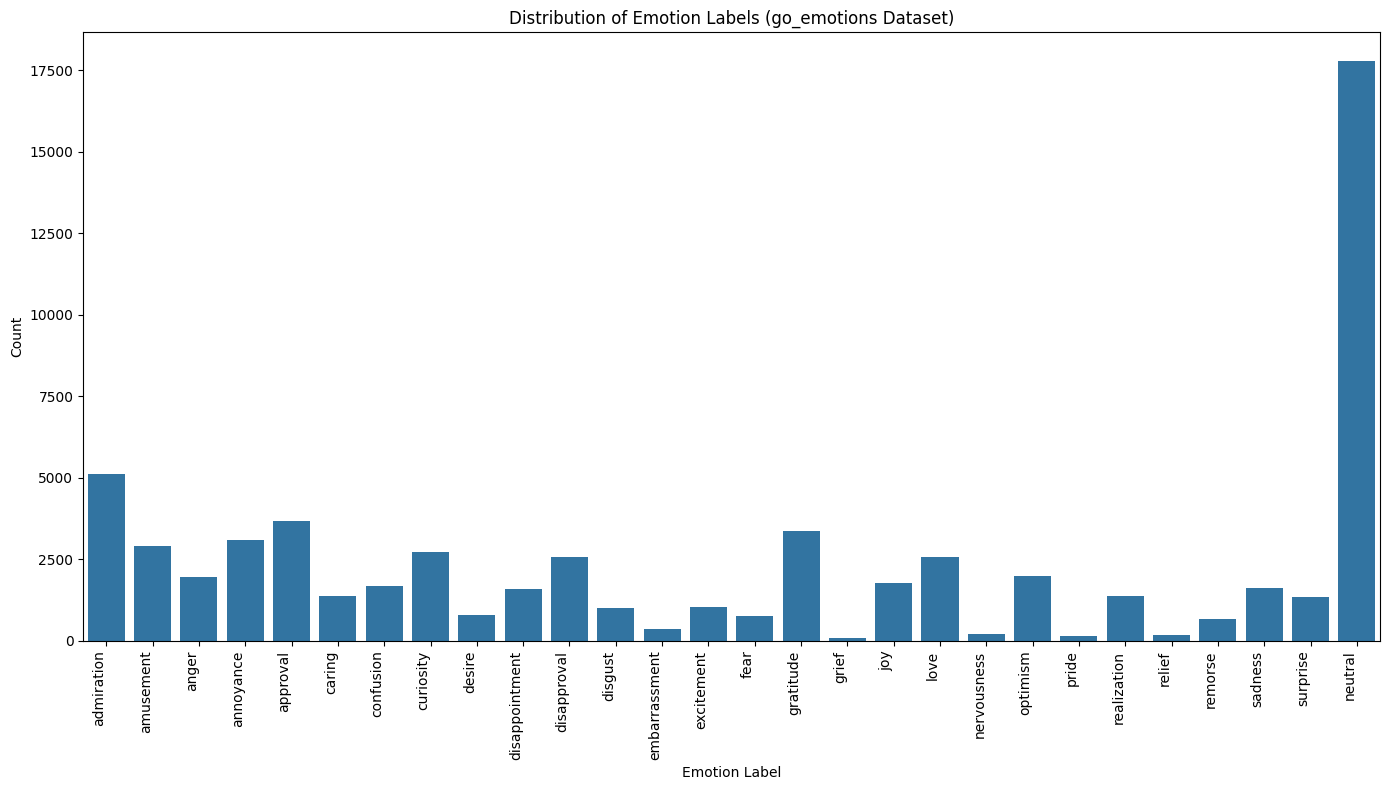


Distribution of Emotion Labels (Counts):
emotion
admiration         5122
amusement          2895
anger              1960
annoyance          3093
approval           3687
caring             1375
confusion          1673
curiosity          2723
desire              801
disappointment     1583
disapproval        2581
disgust            1013
embarrassment       375
excitement         1052
fear                764
gratitude          3372
grief                96
joy                1785
love               2576
nervousness         208
neutral           17772
optimism           1976
pride               142
realization        1382
relief              182
remorse             669
sadness            1625
surprise           1330
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import Dataset # Although not directly used for the combined_df, it was imported before

# The dataset is a DatasetDict with train, validation, and test splits.
# We need to combine them for plotting the overall distribution.
# go_emotions has a 'labels' column which is a list of integers.
combined_df = pd.concat([
    dataset["train"].to_pandas(),
    dataset["validation"].to_pandas(),
    dataset["test"].to_pandas()
])

# The 'labels' column in go_emotions is a list of integers.
# To count the occurrences of each label across all samples, we need to
# "explode" the list of labels into individual rows.
labels_exploded = combined_df.explode('labels')

# Get the value counts of the exploded 'labels' column
# Note: go_emotions dataset doesn't directly provide a label_to_emotion mapping
# in the dataset features. We would typically need a separate mapping or infer it
# from the dataset card or documentation if needed for explicit emotion names.
# For now, we'll plot using the integer labels.

# The emotion names for go_emotions dataset are available in the dataset card:
# 0: admiration, 1: amusement, 2: anger, 3: annoyance, 4: approval, 5: caring,
# 6: confusion, 7: curiosity, 8: desire, 9: disappointment, 10: disapproval,
# 11: disgust, 12: embarrassment, 13: excitement, 14: fear, 15: gratitude,
# 16: grief, 17: joy, 18: love, 19: nervousness, 20: optimism, 21: pride,
# 22: realization, 23: relief, 24: remorse, 25: sadness, 26: surprise, 27: neutral
# Let's create a mapping for better visualization

go_emotions_label_to_emotion = {
    0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance', 4: 'approval',
    5: 'caring', 6: 'confusion', 7: 'curiosity', 8: 'desire', 9: 'disappointment',
    10: 'disapproval', 11: 'disgust', 12: 'embarrassment', 13: 'excitement',
    14: 'fear', 15: 'gratitude', 16: 'grief', 17: 'joy', 18: 'love',
    19: 'nervousness', 20: 'optimism', 21: 'pride', 22: 'realization', 23: 'relief',
    24: 'remorse', 25: 'sadness', 26: 'surprise', 27: 'neutral'
}


# Map the numerical labels to emotion names for plotting after exploding
labels_exploded['emotion'] = labels_exploded['labels'].map(go_emotions_label_to_emotion)


# Get the value counts of the 'emotion' column for plotting
# Sort by index to keep the numerical order of original labels if needed, or sort by counts
emotion_counts = labels_exploded['emotion'].value_counts().sort_index()


# Plot the distribution of the 'emotion' column
plt.figure(figsize=(14, 8)) # Increased figure size for 28 labels
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, order=go_emotions_label_to_emotion.values()) # Use emotion names on x-axis and define order
plt.title('Distribution of Emotion Labels (go_emotions Dataset)')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

print("\nDistribution of Emotion Labels (Counts):")
print(emotion_counts)

In [4]:
from datasets import Dataset

print("="*60)
print("CLEANING DATA & ADDING CONTROL TOKENS")
print("="*60)

# Map for all 28 go_emotions dataset labels
EMOTION_MAP = {
    0: "[ADMIRATION]", 1: "[AMUSEMENT]", 2: "[ANGER]", 3: "[ANNOYANCE]", 4: "[APPROVAL]",
    5: "[CARING]", 6: "[CONFUSION]", 7: "[CURIOUSITY]", 8: "[DESIRE]", 9: "[DISAPPOINTMENT]",
    10: "[DISAPPROVAL]", 11: "[DISGUST]", 12: "[EMBARRASSMENT]", 13: "[EXCITEMENT]",
    14: "[FEAR]", 15: "[GRATITUDE]", 16: "[GRIEF]", 17: "[JOY]", 18: "[LOVE]",
    19: "[NERVOUSNESS]", 20: "[OPTIMISM]", 21: "[PRIDE]", 22: "[REALIZATION]", 23: "[RELIEF]",
    24: "[REMORSE]", 25: "[SADNESS]", 26: "[SURPRISE]", 27: "[NEUTRAL]"
}

# Reverse map for quick lookup of integer labels
REVERSE_EMOTION_MAP = {v: k for k, v in EMOTION_MAP.items()}


def clean_text(text):
    # Ensure the input is a string
    if not isinstance(text, str):
        return None
    text = re.sub(r'http\S+|@\w+|#', '', text)
    # Allow apostrophes, commas, periods, question marks, and exclamation points within words
    text = re.sub(r'[^A-Za-z0-9\s\'\.\,!?]', '', text)
    text = re.sub(r'([!?.,])\1+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Add a minimum length check and diversity check
    if len(text) < 20 or len(set(text.lower())) < 5: # Reduced diversity check to 5 unique characters
        return None
    return text

rows = []
# go_emotions dataset has a 'labels' column which is a list of integers
# Process each example in the combined dataset.
for example in combined:
    cleaned = clean_text(example["text"])
    # Ensure cleaned text is valid and there's at least one label
    if cleaned and example["labels"]:
        # Use the first label from the original list of labels
        primary_label = example["labels"][0]
        # Get the corresponding emotion prefix if the primary label is in our map
        prefix = EMOTION_MAP.get(primary_label, "") # Use get with default for safety

        # Add the emotion prefix (if found) and the cleaned text
        # Store the primary label as the single label for this row
        rows.append({"text": f"{prefix} {cleaned}".strip(), "label": primary_label})


# Create a Hugging Face Dataset from the processed rows
# Convert to pandas DataFrame first to handle the list of dicts structure easily
cleaned_ds = Dataset.from_pandas(pd.DataFrame(rows))
print(f"After cleaning and converting to single-label: {len(cleaned_ds)} samples")

CLEANING DATA & ADDING CONTROL TOKENS
After cleaning and converting to single-label: 49342 samples


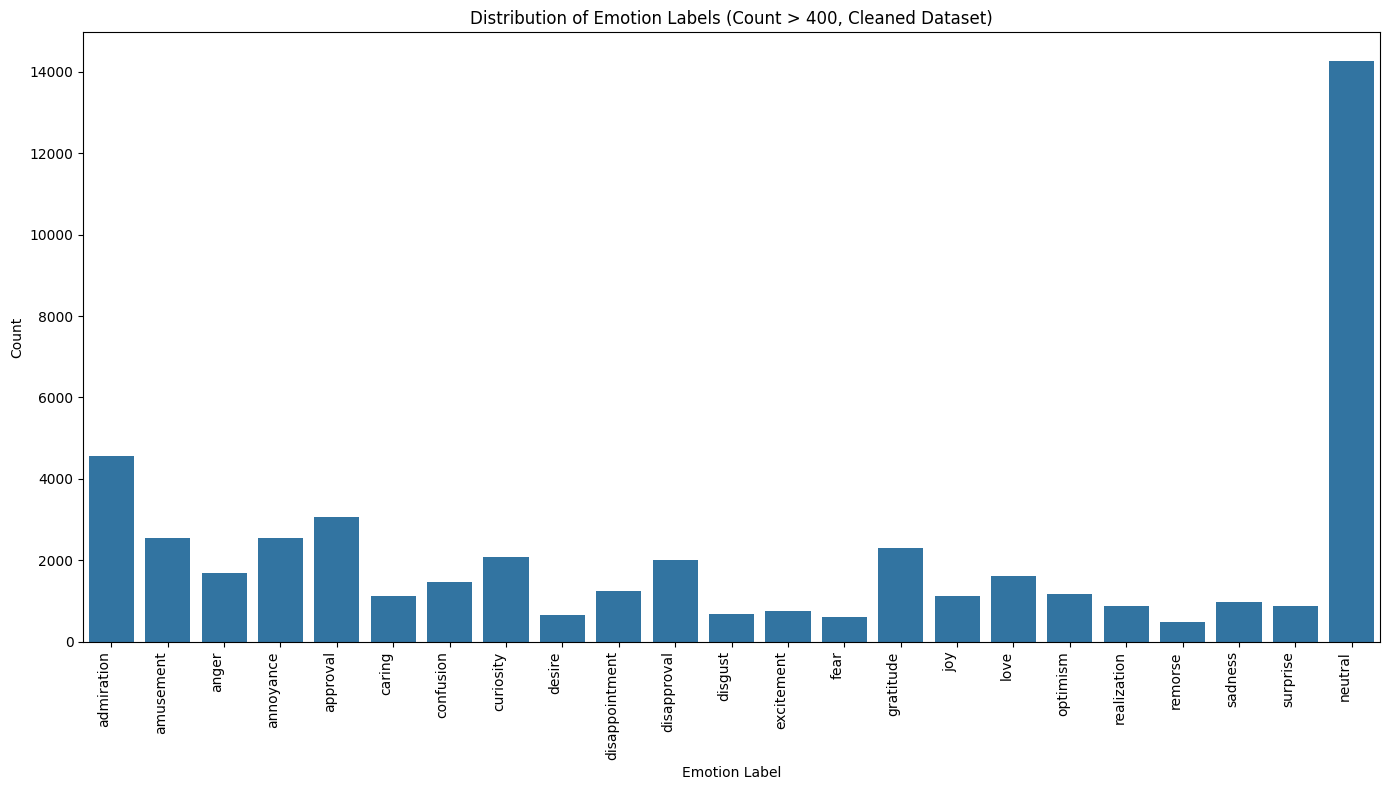


Emotions with count > 400 (23 out of 28 total):
admiration: 4572
amusement: 2544
anger: 1676
annoyance: 2547
approval: 3060
caring: 1124
confusion: 1469
curiosity: 2085
desire: 661
disappointment: 1237
disapproval: 2011
disgust: 684
excitement: 743
fear: 610
gratitude: 2303
joy: 1128
love: 1616
optimism: 1179
realization: 876
remorse: 471
sadness: 961
surprise: 865
neutral: 14257


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the cleaned_ds dataset to a pandas DataFrame for plotting
cleaned_df = cleaned_ds.to_pandas()

# Map the numerical labels to emotion names for plotting
if 'go_emotions_label_to_emotion' in locals() or 'go_emotions_label_to_emotion' in globals():
    cleaned_df['emotion'] = cleaned_df['label'].map(go_emotions_label_to_emotion)

    # Get the value counts of the 'emotion' column
    emotion_counts_cleaned = cleaned_df['emotion'].value_counts()

    # Filter labels with count above 400
    emotion_counts_filtered = emotion_counts_cleaned[emotion_counts_cleaned > 400]

    # Get the order based on original label numbers (for consistency)
    emotion_order = []
    for label_num in sorted(cleaned_df['label'].unique()):
        emotion_name = go_emotions_label_to_emotion.get(label_num)
        if emotion_name in emotion_counts_filtered.index:
            emotion_order.append(emotion_name)

    # Plot the distribution of emotions with count > 400
    plt.figure(figsize=(14, 8))
    sns.barplot(x=emotion_counts_filtered.index, y=emotion_counts_filtered.values,
                order=emotion_order)
    plt.title('Distribution of Emotion Labels (Count > 400, Cleaned Dataset)')
    plt.xlabel('Emotion Label')
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nEmotions with count > 400 ({len(emotion_counts_filtered)} out of {len(emotion_counts_cleaned)} total):")
    for emotion in emotion_order:
        print(f"{emotion}: {emotion_counts_filtered[emotion]}")

else:
    print("Error: go_emotions_label_to_emotion mapping not found. Cannot plot with emotion names.")
    # Fallback to plotting with numerical labels if mapping is missing
    label_counts_cleaned = cleaned_df['label'].value_counts().sort_index()

    # Filter numerical labels with count above 400
    label_counts_filtered = label_counts_cleaned[label_counts_cleaned > 400]

    plt.figure(figsize=(14, 8))
    sns.barplot(x=label_counts_filtered.index, y=label_counts_filtered.values)
    plt.title('Distribution of Emotion Labels (Count > 400, Cleaned Dataset - Numerical)')
    plt.xlabel('Emotion Label (Numerical)')
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nLabels with count > 400 ({len(label_counts_filtered)} out of {len(label_counts_cleaned)} total):")
    print(label_counts_filtered)


In [6]:
from datasets import Dataset
import pandas as pd # Ensure pandas is imported

print("="*60)
print("CREATING BALANCED DATASET (Filtered by count > 400)")
print("="*60)

# Convert the cleaned_ds to pandas to easily filter by label counts
cleaned_df = cleaned_ds.to_pandas()

# Calculate label counts from the cleaned single-label dataset
label_counts_cleaned = cleaned_df['label'].value_counts()

# Identify labels with counts greater than 400
labels_to_include = label_counts_cleaned[label_counts_cleaned > 400].index.tolist()

print(f"Including labels with counts > 400: {labels_to_include}")

# Filter the cleaned_ds to only include samples with labels in labels_to_include
filtered_ds = cleaned_ds.filter(lambda example: example['label'] in labels_to_include)

# Convert filtered dataset to pandas to get the minimum count for balancing
filtered_df = filtered_ds.to_pandas()

# Calculate the minimum count among the included labels
if not filtered_df.empty:
    min_count = filtered_df["label"].value_counts().min()
    print(f"Minimum count among included labels: {min_count}")
else:
    min_count = 0
    print("No labels with counts > 400 found. Minimum count is 0.")


balanced = []
# Balance only the labels that are included
for label in labels_to_include:
    subset = filtered_ds.filter(lambda x: x["label"] == label)
    # Check if the subset is not empty before selecting
    if len(subset) > 0:
        # Use the minimum count across the *filtered* labels for balancing
        balanced.append(subset.shuffle(seed=42).select(range(min_count)))
    else:
        # This case should theoretically not happen if labels_to_include is correct,
        # but keeping for safety.
        print(f"Warning: No samples found in filtered_ds for label {label}. Skipping.")


if balanced:
    balanced_ds = concatenate_datasets(balanced).shuffle(seed=42)
    print("Balanced size:", len(balanced_ds))
    print("Balanced label counts:")
    # Use filtered_df to get the emotion names mapping for better readability
    # Assuming go_emotions_label_to_emotion is available
    if 'go_emotions_label_to_emotion' in globals():
         balanced_df_temp = balanced_ds.to_pandas()
         balanced_df_temp['emotion'] = balanced_df_temp['label'].map(go_emotions_label_to_emotion)
         print(balanced_df_temp['emotion'].value_counts().sort_index())
    else:
         print(balanced_ds.to_pandas()["label"].value_counts().sort_index()) # Sort index for better readability
else:
    balanced_ds = Dataset.from_pandas(pd.DataFrame({"text": [], "label": []}))
    print("No balanced dataset created as no labels met the criteria.")

CREATING BALANCED DATASET (Filtered by count > 400)
Including labels with counts > 400: [27, 0, 4, 3, 1, 15, 7, 10, 2, 18, 6, 9, 20, 17, 5, 25, 22, 26, 13, 11, 8, 14, 24]


Filter:   0%|          | 0/49342 [00:00<?, ? examples/s]

Minimum count among included labels: 471


Filter:   0%|          | 0/48679 [00:00<?, ? examples/s]

Filter:   0%|          | 0/48679 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/48679 [00:00<?, ? examples/s]

Filter:   0%|          | 0/48679 [00:00<?, ? examples/s]

Filter:   0%|          | 0/48679 [00:00<?, ? examples/s]

Filter:   0%|          | 0/48679 [00:00<?, ? examples/s]

Balanced size: 10833
Balanced label counts:
emotion
admiration        471
amusement         471
anger             471
annoyance         471
approval          471
caring            471
confusion         471
curiosity         471
desire            471
disappointment    471
disapproval       471
disgust           471
excitement        471
fear              471
gratitude         471
joy               471
love              471
neutral           471
optimism          471
realization       471
remorse           471
sadness           471
surprise          471
Name: count, dtype: int64


In [7]:
from datasets import ClassLabel

print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)

# Define the ClassLabel feature for all 28 go_emotions labels
# Use the emotion names from the go_emotions_label_to_emotion map defined earlier
emotion_names_28 = list(go_emotions_label_to_emotion.values())
emotion_classlabel_28 = ClassLabel(names=emotion_names_28)

# Convert the 'label' column to ClassLabel type
balanced_ds = balanced_ds.cast_column('label', emotion_classlabel_28)

# Perform the train-test split with stratification
split = balanced_ds.train_test_split(test_size=0.1, seed=42, stratify_by_column="label")
train_ds, test_ds = split["train"], split["test"]

print(f"Train: {len(train_ds)} samples")
print(f"Test : {len(test_ds)} samples")

# Optional: Verify the class distribution in train and test sets
import pandas as pd
print("\nClass distribution in train set:")
print(pd.Series(train_ds['label']).value_counts(normalize=True).sort_index()) # Sort index for better readability

print("\nClass distribution in test set:")
print(pd.Series(test_ds['label']).value_counts(normalize=True).sort_index()) # Sort index for better readability

TRAIN/TEST SPLIT


Casting the dataset:   0%|          | 0/10833 [00:00<?, ? examples/s]

Train: 9749 samples
Test : 1084 samples

Class distribution in train set:
0     0.043492
1     0.043492
2     0.043492
3     0.043492
4     0.043389
5     0.043492
6     0.043492
7     0.043492
8     0.043492
9     0.043492
10    0.043492
11    0.043492
13    0.043492
14    0.043492
15    0.043492
17    0.043389
18    0.043389
20    0.043492
22    0.043492
24    0.043492
25    0.043492
26    0.043492
27    0.043492
Name: proportion, dtype: float64

Class distribution in test set:
0     0.043358
1     0.043358
2     0.043358
3     0.043358
4     0.044280
5     0.043358
6     0.043358
7     0.043358
8     0.043358
9     0.043358
10    0.043358
11    0.043358
13    0.043358
14    0.043358
15    0.043358
17    0.044280
18    0.044280
20    0.043358
22    0.043358
24    0.043358
25    0.043358
26    0.043358
27    0.043358
Name: proportion, dtype: float64


In [8]:
print("="*60)
print("LOADING SmolLM-135M-Instruct and adding all above 400 count go_emotions tokens")
print("="*60)

MODEL_NAME = "HuggingFaceTB/SmolLM-135M-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# Add all 28 emotion tokens from the EMOTION_MAP
tokenizer.add_special_tokens({"additional_special_tokens": list(EMOTION_MAP.values())})

tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto")
model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = tokenizer.eos_token_id

print(f"Model parameters: {model.num_parameters():,}")

LOADING SmolLM-135M-Instruct and adding all 28 go_emotions tokens


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model parameters: 134,531,136


In [9]:
print("="*60)
print("TOKENIZING DATASETS")
print("="*60)

max_length = 128

def tokenize_fn(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized_train = train_ds.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text","label"]
)
tokenized_test = test_ds.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text","label"]
)

print(f"Tokenized train: {len(tokenized_train)}")
print(f"Tokenized test : {len(tokenized_test)}")


TOKENIZING DATASETS


Map:   0%|          | 0/9749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1084 [00:00<?, ? examples/s]

Tokenized train: 9749
Tokenized test : 1084


In [12]:
print("="*60)
print("SETTING UP TRAINING ARGUMENTS")
print("="*60)

training_args = TrainingArguments(
    output_dir="./smollm135m-sentiment",
    overwrite_output_dir=True,
    num_train_epochs=6,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    logging_steps=75,
    eval_strategy="steps",
    eval_steps=150,
    save_strategy="steps",
    save_steps=150,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    group_by_length=True,
    report_to="none",
    #callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

eff_batch = training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps
print(f"Effective batch size: {eff_batch}")


SETTING UP TRAINING ARGUMENTS
Effective batch size: 64


In [13]:
print("="*60)
print("INITIALIZING TRAINER")
print("="*60)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator
)

print("🚀 Starting training...")
train_result = trainer.train()
print(f"✅ Training loss: {train_result.training_loss:.4f}")

eval_results = trainer.evaluate()
print(f"📊 Eval loss  : {eval_results['eval_loss']:.4f}")
print(f"📊 Perplexity : {math.exp(eval_results['eval_loss']):.2f}")


INITIALIZING TRAINER
🚀 Starting training...


Step,Training Loss,Validation Loss
150,3.966400,4.147373
300,3.438400,4.203318
450,2.845300,4.482911
600,2.253900,5.025477
750,1.745700,5.667774
900,1.405600,6.123893


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


✅ Training loss: 2.6224


📊 Eval loss  : 4.1512
📊 Perplexity : 63.51


In [14]:
import os

# Define the directory to save the model and tokenizer
save_directory = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\smollm"

# Create the directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

# Save the trained model
trainer.save_model(save_directory)

# Save the tokenizer
tokenizer.save_pretrained(save_directory)

print(f"Trained model and tokenizer saved to {save_directory}")

Trained model and tokenizer saved to C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\smollm


In [15]:
import re

def generate_multiple_texts(prompt, model, tokenizer, device="cuda", num_outputs=5):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,              # Sampling enabled for diversity
        temperature=0.75,
        top_k=40,
        top_p=0.9,
        repetition_penalty=1.3,
        length_penalty=1.2,
        num_beams=1,
        no_repeat_ngram_size=3,
        num_return_sequences=num_outputs,
        early_stopping=True,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_texts = []
    for output in outputs:
        text = tokenizer.decode(output, skip_special_tokens=True)
        # Clean output
        text = re.sub(r'([!?.,])\1+', r'\1', text)
        text = re.sub(r'[^A-Za-z0-9 \.\,!?]+', '', text)
        text = re.sub(r'\b(\w+)\1{2,}', r'\1', text)
        text = re.sub(r'\s+', ' ', text).strip()
        generated_texts.append(text)

    return generated_texts

# Emotion prefixes for the labels that were included in the balanced dataset (counts > 400)
# Assuming labels_to_include and EMOTION_MAP are available from previous cells
if 'labels_to_include' in globals() and 'EMOTION_MAP' in globals():
    emotions_to_generate = [EMOTION_MAP[label] for label in labels_to_include if label in EMOTION_MAP]
else:
    # Fallback to all emotions if labels_to_include or EMOTION_MAP are not found
    print("Warning: 'labels_to_include' or 'EMOTION_MAP' not found. Generating samples for all 28 emotions.")
    emotions_to_generate = list(EMOTION_MAP.values())


prompt_stem = "I feel"

all_samples = {}
num_samples_per_emotion = 3 # Reduced number of samples for quicker testing

for emotion in emotions_to_generate:
    prompt = f"{emotion} {prompt_stem}"
    samples = generate_multiple_texts(prompt, model, tokenizer, num_outputs=num_samples_per_emotion)
    all_samples[emotion] = samples

# Print generative samples grouped by emotion
for emotion, samples in all_samples.items():
    print(f"\n===== Samples for emotion: {emotion} =====\n")
    for i, sample in enumerate(samples, 1):
        print(f"Sample {i}: {sample}\n")

The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



===== Samples for emotion: [NEUTRAL] =====

Sample 1: I feel like theyre just going to get more people who really need it. They should have done better with a smaller team and less money, but thats the kind of team I want for me now in my career right? The best thing about NAME

Sample 2: I feel like you just need to go back and find the truth of this whole thing. Good luck on your journey, friends! Hope the whole world is doing good too! Thank you for sharing! Best of luck out there in a new year! Lma

Sample 3: I feel like this is a huge thing that should happen. People are just not happy with the way their country works and its getting better, but people still live in an abusive environment so we shouldnt be putting them at risk to say things they dont


===== Samples for emotion: [ADMIRATION] =====

Sample 1: I feel like hes a bit of a fucking good boy. But I dont know why he likes that. It would have to be the best boy in the whole series, right? And the girl is so fun!? Whats wr

# Dataset augmentation

In [1]:
import re
import random
import pandas as pd
from datasets import load_dataset, concatenate_datasets
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load original go_emotions dataset
# We will use the combined dataset for potential augmentation purposes
dataset = load_dataset("go_emotions")
combined = concatenate_datasets([
    dataset["train"], dataset["validation"], dataset["test"]
])

# Load your fine-tuned generative model and tokenizer (SmolLM fine-tuned on go_emotions)
# Update the save_path to where you saved the SmolLM model fine-tuned on go_emotions
save_path = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\smollm" # Assuming this is the correct path
model = AutoModelForCausalLM.from_pretrained(save_path).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(save_path)

print(f"Loaded go_emotions dataset with {len(combined)} samples.")
print(f"Loaded SmolLM model and tokenizer from {save_path}")

# Note: The generative quality of this model for some labels was observed to be poor.
# This might affect the effectiveness of the augmentation process if it relies on generated text quality.

Loaded go_emotions dataset with 54263 samples.
Loaded SmolLM model and tokenizer from C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\smollm


In [2]:
def generate_multiple_texts(prompt_list, model, tokenizer, device="cuda", num_outputs=1):
    generated_texts = []
    # Tokenize the entire batch of prompts
    inputs = tokenizer(prompt_list, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.75,
        top_k=40,
        top_p=0.9,
        repetition_penalty=1.3,
        length_penalty=1.2,
        num_beams=1,
        no_repeat_ngram_size=3,
        num_return_sequences=num_outputs,
        early_stopping=True,
        pad_token_id=tokenizer.eos_token_id
    )

    # Decode and clean the generated texts
    for output in outputs:
        text = tokenizer.decode(output, skip_special_tokens=True)
        # Clean output: remove the original prompt (this will be tricky with batching, might need a different approach or simpler cleaning),
        # remove special tokens again just in case, remove repeated punctuation,
        # remove non-alphanumeric characters except allowed ones, remove repeated words, and clean up whitespace.

        # A simpler cleaning approach for batch generation, focusing on removing the emotion prefix
        # Create a regex pattern to match any of the 28 emotion tokens
        emotion_tokens_pattern = '|'.join(re.escape(token) for token in EMOTION_MAP.values())
        cleaned_text = re.sub(emotion_tokens_pattern, '', text) # Remove emotion prefix tokens
        cleaned_text = re.sub(r'([!?.,])\1+', r'\1', cleaned_text)
        cleaned_text = re.sub(r'[^A-Za-z0-9 \.\,!?\'\"]+', '', cleaned_text) # Added single and double quotes
        cleaned_text = re.sub(r'\b(\w+)\s+\1\b', r'\1', cleaned_text) # Remove immediate word repetitions
        cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

        # Add a minimum length check for generated text
        if len(cleaned_text) > 10: # Ensure generated text has some substance
             generated_texts.append(cleaned_text)
        else:
             # Optionally, log or handle cases where generated text is too short
             pass # print(f"Skipping short generated text: {cleaned_text}")


    return generated_texts

In [3]:
# Expand your seed prompts for maximum diversity based on emotion labels
seed_stems = {
    "[ADMIRATION]": [
        "I feel admiration for", "This makes me feel admired by", "Feeling absolutely appreciative today",
        "I'm impressed with", "Experiencing immense respect due to", "This situation makes me feel reverent",
        "Feeling a strong sense of awe for", "I'm so thankful for", "This kindness makes me feel esteemed",
        "Feeling admiring and appreciative towards", "I feel like commending because", "Everything feels grand and I'm filled with",
        "Feeling utterly impressed by", "This achievement is making me feel very admiring", "I feel a sense of wonder because",
        "It's inspiring to feel admiration when", "Feeling appreciative and respectful towards", "This gesture makes me feel deeply impressed",
        "I'm in a state of reverence because", "Feeling utterly awestruck with"
    ],
    "[AMUSEMENT]": [
        "I find this amusing because", "This makes me feel entertained", "Feeling absolutely jovial today",
        "I'm tickled by", "Experiencing intense amusement due to", "This situation makes me feel lighthearted",
        "Feeling a strong sense of humor about", "I'm so entertained by", "This joke makes me feel cheerful",
        "Feeling amused and merry about", "I feel like laughing because", "Everything feels funny and I'm filled with",
        "Feeling utterly entertained by", "This comedy is making me feel very amused", "I feel a sense of glee because",
        "It's fun to feel amusement when", "Feeling cheerful and lighthearted about", "This performance makes me feel deeply entertained",
        "I'm in a state of mirth because", "Feeling utterly delighted with"
    ],
    "[ANGER]": [
        "I am so angry because", "This makes me feel furious", "Feeling absolutely enraged today",
        "I'm pissed off with", "Experiencing intense anger due to", "This situation makes me feel resentful",
        "Feeling a strong sense of irritation with", "I'm so frustrated about", "This unfairness makes me feel irate",
        "Feeling hostile and aggressive towards", "I feel like screaming because", "Everything feels wrong and I'm filled with",
        "Feeling utterly incensed about", "This betrayal is making me feel very angry", "I feel a burning rage because",
        "It's hard to stay calm when", "Feeling bitter and annoyed by", "This obstacle makes me feel furious",
        "I'm in a state of wrath because", "Feeling utterly exasperated about"
    ],
    "[ANNOYANCE]": [
        "I am so annoyed because", "This makes me feel irritated", "Feeling absolutely exasperated today",
        "I'm bothered by", "Experiencing intense annoyance due to", "This situation makes me feel vexed",
        "Feeling a strong sense of frustration with", "I'm so irritated by", "This inconvenience makes me feel irked",
        "Feeling annoyed and testy about", "I feel like sighing because", "Everything feels grating and I'm filled with",
        "Feeling utterly exasperated by", "This delay is making me feel very annoyed", "I feel a sense of impatience because",
        "It's frustrating to feel annoyance when", "Feeling bothered and peevish about", "This behavior makes me feel deeply irritated",
        "I'm in a state of aggravation because", "Feeling utterly irked with"
    ],
    "[APPROVAL]": [
        "I approve of this because", "This makes me feel approving", "Feeling absolutely in agreement today",
        "I'm supportive of", "Experiencing intense approval due to", "This situation makes me feel endorsing",
        "Feeling a strong sense of validation for", "I'm so pleased with", "This decision makes me feel agreeable",
        "Feeling approving and confirming towards", "I feel like endorsing because", "Everything feels right and I'm filled with",
        "Feeling utterly validating about", "This outcome is making me feel very approving", "I feel a sense of affirmation because",
        "It's reassuring to feel approval when", "Feeling supportive and agreeable towards", "This progress makes me feel deeply approving",
        "I'm in a state of confirmation because", "Feeling utterly endorsing of"
    ],
    "[CARING]": [
        "I feel caring towards", "This makes me feel empathetic", "Feeling absolutely compassionate today",
        "I'm concerned about", "Experiencing intense caring due to", "This situation makes me feel nurturing",
        "Feeling a strong sense of concern for", "I'm so worried about", "This person makes me feel sympathetic",
        "Feeling caring and benevolent towards", "I feel like helping because", "Everything feels important and I'm filled with",
        "Feeling utterly compassionate about", "This vulnerability is making me feel very caring", "I feel a sense of empathy because",
        "It's good to feel caring when", "Feeling concerned and sympathetic towards", "This need makes me feel deeply caring",
        "I'm in a state of solicitude because", "Feeling utterly nurturing of"
    ],
    "[CONFUSION]": [
        "I am so confused because", "This makes me feel puzzled", "Feeling absolutely bewildered today",
        "I'm unsure about", "Experiencing intense confusion due to", "This situation makes me feel perplexed",
        "Feeling a strong sense of uncertainty about", "I'm so confused by", "This information makes me feel disoriented",
        "Feeling confused and mystified about", "I feel like questioning because", "Everything feels unclear and I'm filled with",
        "Feeling utterly bewildered about", "This ambiguity is making me feel very confused", "I feel a sense of doubt because",
        "It's strange to feel confusion when", "Feeling puzzled and uncertain about", "This explanation makes me feel deeply confused",
        "I'm in a state of perplexity because", "Feeling utterly mystified by"
    ],
    "[CURIOUSITY]": [
        "I am so curious because", "This makes me feel inquisitive", "Feeling absolutely eager to know today",
        "I'm interested in", "Experiencing intense curiosity due to", "This situation makes me feel exploring",
        "Feeling a strong sense of wonder about", "I'm so intrigued by", "This mystery makes me feel exploring",
        "Feeling curious and eager about", "I feel like investigating because", "Everything feels interesting and I'm filled with",
        "Feeling utterly inquisitive about", "This topic is making me feel very curious", "I feel a sense of wonder because",
        "It's fascinating to feel curiosity when", "Feeling eager and interested about", "This discovery makes me feel deeply curious",
        "I'm in a state of inquiry because", "Feeling utterly intrigued by"
    ],
     "[DESIRE]": [
        "I desire this because", "This makes me feel desirous", "Feeling absolutely longing today",
        "I'm yearning for", "Experiencing intense desire due to", "This situation makes me feel craving",
        "Feeling a strong sense of longing for", "I'm so wanting of", "This makes me feel eager",
        "Feeling desirous and covetous towards", "I feel like pursuing because", "Everything feels appealing and I'm filled with",
        "Feeling utterly longing for", "This opportunity is making me feel very desirous", "I feel a sense of yearning because",
        "It's exciting to feel desire when", "Feeling eager and covetous towards", "This prospect makes me feel deeply desirous",
        "I'm in a state of craving because", "Feeling utterly yearning for"
    ],
    "[DISAPPOINTMENT]": [
        "I am so disappointed because", "This makes me feel let down", "Feeling absolutely disheartened today",
        "I'm disillusioned with", "Experiencing intense disappointment due to", "This situation makes me feel saddened",
        "Feeling a strong sense of regret about", "I'm so disappointed by", "This outcome makes me feel displeased",
        "Feeling disappointed and crestfallen about", "I feel like giving up because", "Everything feels bleak and I'm filled with",
        "Feeling utterly let down by", "This failure is making me feel very disappointed", "I feel a sense of dismay because",
        "It's hard to feel happy when", "Feeling disheartened and displeased by", "This result makes me feel deeply disappointed",
        "I'm in a state of disillusionment because", "Feeling utterly crestfallen about"
    ],
    "[DISAPPROVAL]": [
        "I disapprove of this because", "This makes me feel disapproving", "Feeling absolutely against this today",
        "I'm opposed to", "Experiencing intense disapproval due to", "This situation makes me feel critical",
        "Feeling a strong sense of objection to", "I'm so displeased with", "This behavior makes me feel unfavorable",
        "Feeling disapproving and critical towards", "I feel like objecting because", "Everything feels wrong and I'm filled with",
        "Feeling utterly against this", "This action is making me feel very disapproving", "I feel a sense of dissent because",
        "It's hard to accept when", "Feeling critical and unfavorable towards", "This decision makes me feel deeply disapproving",
        "I'm in a state of opposition because", "Feeling utterly displeased with"
    ],
    "[DISGUST]": [
        "I feel disgust because", "This makes me feel repulsed", "Feeling absolutely nauseated today",
        "I'm revolted by", "Experiencing intense disgust due to", "This situation makes me feel offended",
        "Feeling a strong sense of aversion to", "I'm so disgusted by", "This makes me feel sickened",
        "Feeling disgusted and revolted by", "I feel like recoiling because", "Everything feels foul and I'm filled with",
        "Feeling utterly repulsed by", "This sight is making me feel very disgusted", "I feel a sense of revulsion because",
        "It's sickening to feel disgust when", "Feeling nauseated and offended by", "This smell makes me feel deeply disgusted",
        "I'm in a state of loathing because", "Feeling utterly sickened by"
    ],
    "[EMBARRASSMENT]": [
        "I feel embarrassed because", "This makes me feel sheepish", "Feeling absolutely mortified today",
        "I'm ashamed of", "Experiencing intense embarrassment due to", "This situation makes me feel awkward",
        "Feeling a strong sense of shame about", "I'm so embarrassed by", "This mistake makes me feel red-faced",
        "Feeling embarrassed and humiliated about", "I feel like hiding because", "Everything feels awkward and I'm filled with",
        "Feeling utterly mortified by", "This incident is making me feel very embarrassed", "I feel a sense of awkwardness because",
        "It's cringeworthy to feel embarrassment when", "Feeling sheepish and ashamed about", "This comment makes me feel deeply embarrassed",
        "I'm in a state of humiliation because", "Feeling utterly red-faced"
    ],
    "[EXCITEMENT]": [
        "I am so excited because", "This makes me feel thrilled", "Feeling absolutely exhilarated today",
        "I'm eager for", "Experiencing intense excitement due to", "This situation makes me feel energized",
        "Feeling a strong sense of anticipation about", "I'm so hyped for", "This news makes me feel ecstatic",
        "Feeling excited and enthusiastic about", "I feel like jumping because", "Everything feels vibrant and I'm filled with",
        "Feeling utterly thrilled about", "This opportunity is making me feel very excited", "I feel a sense of anticipation because",
        "It's amazing to feel excitement when", "Feeling eager and enthusiastic about", "This event makes me feel deeply excited",
        "I'm in a state of euphoria because", "Feeling utterly energized by"
    ],
    "[FEAR]": [
        "I am so scared because", "This makes me feel fearful", "Feeling absolutely terrified today",
        "I'm afraid of", "Experiencing intense fear due to", "This situation makes me feel anxious",
        "Feeling a strong sense of dread about", "I'm so worried about", "This uncertainty makes me feel uneasy",
        "Feeling nervous and apprehensive about", "I feel like hiding because", "Everything feels dangerous and I'm filled with",
        "Feeling utterly petrified about", "This threat is making me feel very scared", "I feel a chilling fear because",
        "It's hard to feel safe when", "Feeling timid and insecure about", "This risk makes me feel frightened",
        "I'm in a state of panic because", "Feeling utterly alarmed about"
    ],
    "[GRATITUDE]": [
        "I am so grateful because", "This makes me feel thankful", "Feeling absolutely appreciative today",
        "I'm indebted to", "Experiencing intense gratitude due to", "This situation makes me feel blessed",
        "Feeling a strong sense of thankfulness for", "I'm so thankful for", "This help makes me feel appreciative",
        "Feeling grateful and thankful towards", "I feel like thanking because", "Everything feels good and I'm filled with",
        "Feeling utterly grateful for", "This support is making me feel very thankful", "I feel a sense of appreciation because",
        "It's wonderful to feel gratitude when", "Feeling thankful and appreciative towards", "This gift makes me feel deeply grateful",
        "I'm in a state of thankfulness because", "Feeling utterly blessed by"
    ],
    "[GRIEF]": [
        "I feel grief because", "This makes me feel sorrowful", "Feeling absolutely heartbroken today",
        "I'm mourning over", "Experiencing intense grief due to", "This situation makes me feel devastated",
        "Feeling a strong sense of loss about", "I'm so sad about", "This makes me feel mournful",
        "Feeling grief-stricken and sorrowful about", "I feel like weeping because", "Everything feels heavy and I'm filled with",
        "Feeling utterly heartbroken by", "This loss is making me feel very sorrowful", "I feel a sense of profound sadness because",
        "It's hard to cope when", "Feeling mournful and devastated by", "This tragedy makes me feel deeply grief-stricken",
        "I'm in a state of sorrow because", "Feeling utterly broken by"
    ],
    "[JOY]": [
        "I am so happy because", "This makes me feel joyful", "Feeling absolutely delighted today",
        "I'm thrilled with", "Experiencing immense joy due to", "This is wonderful and makes me feel",
        "Feeling on top of the world because", "I'm so excited about", "This good news makes me feel great",
        "Feeling cheerful and optimistic about", "I feel like celebrating because", "Everything feels bright and I'm filled with",
        "Feeling utterly ecstatic about", "This success is making me feel very happy", "I feel a light heart because",
        "It's easy to feel happy when", "Feeling positive and uplifted by", "This achievement makes me feel fantastic",
        "I'm in a state of bliss because", "Feeling utterly exhilarated about"
    ],
    "[LOVE]": [
        "I feel so much love for", "This person makes me feel loved", "Feeling a deep connection with",
        "I'm fond of", "Experiencing immense affection for", "This relationship makes me feel warm and fuzzy",
        "Feeling a strong bond with", "I'm so grateful for", "This kindness makes me feel cherished",
        "Feeling loving and compassionate towards", "I feel like hugging because", "Everything feels beautiful and I'm filled with",
        "Feeling utterly devoted to", "This support is making me feel very loved", "I feel a tender heart because",
        "It's wonderful to feel love when", "Feeling affectionate and caring towards", "This gesture makes me feel deeply appreciated",
        "I'm in a state of adoration because", "Feeling utterly smitten with"
    ],
    "[NERVOUSNESS]": [
        "I feel nervous because", "This makes me feel anxious", "Feeling absolutely jittery today",
        "I'm apprehensive about", "Experiencing intense nervousness due to", "This situation makes me feel uneasy",
        "Feeling a strong sense of worry about", "I'm so nervous about", "This makes me feel tense",
        "Feeling nervous and agitated about", "I feel like pacing because", "Everything feels uncertain and I'm filled with",
        "Feeling utterly anxious about", "This upcoming event is making me feel very nervous", "I feel a sense of unease because",
        "It's unsettling to feel nervousness when", "Feeling jittery and apprehensive about", "This pressure makes me feel deeply nervous",
        "I'm in a state of agitation because", "Feeling utterly tense about"
    ],
    "[NEUTRAL]": [
        "I feel neutral about", "This makes me feel indifferent", "Feeling absolutely unbiased today",
        "I'm unconcerned with", "Experiencing a lack of strong emotion due to", "This situation makes me feel detached",
        "Feeling a strong sense of impartiality towards", "I'm so indifferent about", "This doesn't make me feel anything",
        "Feeling neutral and objective about", "I feel like observing because", "Everything feels unremarkable and I'm filled with",
        "Feeling utterly indifferent to", "This event is making me feel very neutral", "I feel a sense of detachment because",
        "It's easy to feel neutral when", "Feeling unbiased and unconcerned with", "This topic makes me feel deeply neutral",
        "I'm in a state of impartiality because", "Feeling utterly detached from"
    ],
    "[OPTIMISM]": [
        "I feel optimistic because", "This makes me feel hopeful", "Feeling absolutely positive today",
        "I'm confident about", "Experiencing intense optimism due to", "This situation makes me feel encouraged",
        "Feeling a strong sense of hope about", "I'm so hopeful for", "This news makes me feel positive",
        "Feeling optimistic and positive about", "I feel like believing because", "Everything feels promising and I'm filled with",
        "Feeling utterly hopeful about", "This opportunity is making me feel very optimistic", "I feel a sense of confidence because",
        "It's good to feel optimistic when", "Feeling positive and encouraged about", "This progress makes me feel deeply optimistic",
        "I'm in a state of hopefulness because", "Feeling utterly confident about"
    ],
    "[PRIDE]": [
        "I feel pride because", "This makes me feel proud", "Feeling absolutely accomplished today",
        "I'm satisfied with", "Experiencing intense pride due to", "This situation makes me feel triumphant",
        "Feeling a strong sense of achievement about", "I'm so proud of", "This success makes me feel dignified",
        "Feeling proud and accomplished about", "I feel like celebrating because", "Everything feels honorable and I'm filled with",
        "Feeling utterly proud of", "This accomplishment is making me feel very proud", "I feel a sense of satisfaction because",
        "It's rewarding to feel pride when", "Feeling accomplished and triumphant about", "This recognition makes me feel deeply proud",
        "I'm in a state of dignity because", "Feeling utterly satisfied with"
    ],
    "[REALIZATION]": [
        "I feel a realization because", "This makes me feel aware", "Feeling absolutely enlightened today",
        "I've come to understand", "Experiencing a sudden realization due to", "This situation makes me feel clear-headed",
        "Feeling a strong sense of understanding about", "I'm so aware of", "This information makes me feel comprehending",
        "Feeling realizing and enlightened about", "I feel like understanding because", "Everything feels clear and I'm filled with",
        "Feeling utterly aware of", "This discovery is making me feel very realizing", "I feel a sense of comprehension because",
        "It's insightful to feel realization when", "Feeling enlightened and comprehending about", "This moment makes me feel deeply realizing",
        "I'm in a state of understanding because", "Feeling utterly clear-headed about"
    ],
    "[RELIEF]": [
        "I feel relief because", "This makes me feel relieved", "Feeling absolutely unburdened today",
        "I'm eased by", "Experiencing intense relief due to", "This situation makes me feel comforted",
        "Feeling a strong sense of ease about", "I'm so relieved by", "This news makes me feel relaxed",
        "Feeling relieved and comforted by", "I feel like relaxing because", "Everything feels light and I'm filled with",
        "Feeling utterly unburdened by", "This outcome is making me feel very relieved", "I feel a sense of ease because",
        "It's calming to feel relief when", "Feeling comforted and relaxed by", "This resolution makes me feel deeply relieved",
        "I'm in a state of ease because", "Feeling utterly relaxed about"
    ],
    "[REMORSE]": [
        "I feel remorse because", "This makes me feel regretful", "Feeling absolutely contrite today",
        "I'm sorry for", "Experiencing intense remorse due to", "This situation makes me feel guilty",
        "Feeling a strong sense of sorrow about", "I'm so regretful about", "This mistake makes me feel penitent",
        "Feeling remorseful and guilty about", "I feel like apologizing because", "Everything feels heavy and I'm filled with",
        "Feeling utterly regretful about", "This action is making me feel very remorseful", "I feel a sense of sorrow because",
        "It's hard to forgive myself when", "Feeling guilty and penitent about", "This consequence makes me feel deeply remorseful",
        "I'm in a state of contrition because", "Feeling utterly sorrowful about"
    ],
    "[SADNESS]": [
        "I feel so sad because", "It makes me unhappy that", "I am feeling down today",
        "This situation is depressing", "I'm heartbroken over", "Feeling a deep sense of sorrow",
        "It's a gloomy day and I feel", "I can't help but feel melancholic about", "This news has made me feel terrible",
        "Experiencing a lot of sadness due to", "I feel like crying because", "Everything feels hopeless when",
        "Feeling utterly miserable about", "This loss is making me feel very low", "I feel a heavy heart because",
        "It's hard to feel happy when", "Feeling blue and discouraged by", "This disappointment makes me feel awful",
        "I'm in a state of sadness because", "Feeling utterly despondent about"
    ],
    "[SURPRISE]": [
        "I am so surprised because", "This makes me feel astonished", "Feeling absolutely amazed today",
        "I'm shocked by", "Experiencing intense surprise due to", "This news makes me feel startled",
        "Feeling a strong sense of wonder about", "I'm so taken aback by", "This unexpected event makes me feel bewildered",
        "Feeling astonished and impressed by", "I feel like gasping because", "Everything feels sudden and I'm filled with",
        "Feeling utterly astounded about", "This revelation is making me feel very surprised", "I feel a sense of awe because",
        "It's exciting to feel surprised when", "Feeling amazed and bewildered by", "This twist makes me feel shocked",
        "I'm in a state of disbelief because", "Feeling utterly flabbergasted about"
    ]
}

# Note: The keys in seed_stems should match the emotion tokens in EMOTION_MAP
# If EMOTION_MAP was defined in a previous cell and used for adding tokens,
# ensure consistency here. Assuming EMOTION_MAP with all 28 labels is available.

In [6]:
from datasets import load_dataset, concatenate_datasets
import pandas as pd

print("="*60)
print("CONVERTING TO SINGLE-LABEL & COUNTING")
print("="*60)

# Load the go_emotions dataset again within this cell
dataset = load_dataset("go_emotions")

# Combine the dataset splits
combined = concatenate_datasets([
    dataset["train"], dataset["validation"], dataset["test"]
])

rows = []
# Process each example to create single-label entries
for example in combined:
    # Ensure there is at least one label
    if example["labels"]:
        # Use the first label from the original list of labels
        primary_label = example["labels"][0]
        rows.append({"text": example["text"], "label": primary_label})


# Create a pandas DataFrame from the single-label data
single_label_df = pd.DataFrame(rows)

# Count label distribution of the single-label data
label_counts = single_label_df['label'].value_counts().sort_index()
print("Single-label counts:")
print(label_counts)

# Calculate max count from the single-label data
max_count = label_counts.max()

CONVERTING TO SINGLE-LABEL & COUNTING
Single-label counts:
label
0      5122
1      2793
2      1936
3      2671
4      3269
5      1218
6      1543
7      2210
8       681
9      1284
10     2117
11      738
12      306
13      862
14      658
15     2681
16       81
17     1250
18     1883
19      132
20     1227
21       74
22      893
23      111
24      497
25     1067
26      938
27    16021
Name: count, dtype: int64


In [10]:
import re
import random
import pandas as pd
from datasets import Dataset

# Assuming single_label_df, label_counts, max_count are available from cell h8bitrry6n_X
# Assuming seed_stems is available from cell ppuB8-t96lzz
# Assuming generate_multiple_texts, model, tokenizer are available from previous cells

# Map for all 28 go_emotions dataset labels (included here as requested)
EMOTION_MAP = {
    0: "[ADMIRATION]", 1: "[AMUSEMENT]", 2: "[ANGER]", 3: "[ANNOYANCE]", 4: "[APPROVAL]",
    5: "[CARING]", 6: "[CONFUSION]", 7: "[CURIOUSITY]", 8: "[DESIRE]", 9: "[DISAPPOINTMENT]",
    10: "[DISAPPROVAL]", 11: "[DISGUST]", 12: "[EMBARRASSMENT]", 13: "[EXCITEMENT]",
    14: "[FEAR]", 15: "[GRATITUDE]", 16: "[GRIEF]", 17: "[JOY]", 18: "[LOVE]",
    19: "[NERVOUSNESS]", 20: "[OPTIMISM]", 21: "[PRIDE]", 22: "[REALIZATION]", 23: "[RELIEF]",
    24: "[REMORSE]", 25: "[SADNESS]", 26: "[SURPRISE]", 27: "[NEUTRAL]"
}

augmented_samples = {"text": [], "label": []}

batch_size = 64  # Increased batch size for faster generation

# Identify labels with counts greater than 400 from the single-label counts
labels_to_augment = label_counts[label_counts > 400].index.tolist()

print(f"Generating synthetic samples for labels with counts > 400, targeting 5000 samples each: {labels_to_augment}")

target_count = 5000

for label_int in labels_to_augment:
    # Find the corresponding emotion token from EMOTION_MAP
    sentiment_token = EMOTION_MAP.get(label_int) # Use get for safety

    if sentiment_token is None:
        print(f"Warning: Emotion token not found for label {label_int}. Skipping.")
        continue

    current_count = label_counts.get(label_int, 0)
    # Generate samples up to the target count (5000)
    samples_needed = target_count - current_count

    if samples_needed <= 0:
        print(f"Label {sentiment_token} already has {current_count} samples, which is >= {target_count}. Skipping generation.")
        continue

    print(f"Generating {samples_needed} samples for {sentiment_token} (Label {label_int}) to reach {target_count}...")

    generated_texts = []
    # Use a more robust loop for generation batches
    while len(generated_texts) < samples_needed:
        batch_prompts = []
        # Select random stems for the current batch
        current_stems = seed_stems.get(sentiment_token, [])
        if not current_stems:
             print(f"Warning: No seed stems found for {sentiment_token}. Skipping generation for this label.")
             break

        for _ in range(batch_size):
            if len(generated_texts) + len(batch_prompts) < samples_needed:
                stem = random.choice(current_stems)
                prompt = f"{sentiment_token} {stem}"
                batch_prompts.append(prompt)
            else:
                break

        if not batch_prompts:
            break

        # Generate texts for the batch
        # Ensure generate_multiple_texts handles a list of prompts and returns a list of generated texts
        # num_outputs=1 to get one text per prompt
        new_texts = generate_multiple_texts(batch_prompts, model, tokenizer, num_outputs=1)
        generated_texts.extend(new_texts)

        # Print progress
        if len(generated_texts) // 100 > (len(generated_texts) - len(new_texts)) // 100: # Print when a new multiple of 100 is reached
             print(f"Generated {len(generated_texts)} samples so far for {sentiment_token}.")


    generated_texts = generated_texts[:samples_needed] # Trim any excess generated samples

    augmented_samples["text"].extend([f"{sentiment_token} {t}" for t in generated_texts])
    augmented_samples["label"].extend([label_int]*samples_needed)

print(f"Total synthetic samples generated: {len(augmented_samples['text'])}")

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generating synthetic samples for labels with counts > 400, targeting 5000 samples each: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 20, 22, 24, 25, 26, 27]
Label [ADMIRATION] already has 5122 samples, which is >= 5000. Skipping generation.
Generating 2207 samples for [AMUSEMENT] (Label 1) to reach 5000...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generated 128 samples so far for [AMUSEMENT].


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


...

Generated 3840 samples so far for [SURPRISE].


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generated 3904 samples so far for [SURPRISE].


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generated 4032 samples so far for [SURPRISE].
Label [NEUTRAL] already has 16021 samples, which is >= 5000. Skipping generation.
Total synthetic samples generated: 72584


In [11]:
import pandas as pd
from datasets import Dataset

# Assuming single_label_df is available from h8bitrry6n_X (or created with single labels)
# Assuming augmented_samples is available from a_ZBN6EZ7IyC

# Convert augmented_samples dictionary to a pandas DataFrame
aug_df = pd.DataFrame(augmented_samples)

# Filter the original single_label_df to include only the labels that were augmented (counts > 400)
# This is to combine the original samples of the augmented labels with the synthetic samples
if 'labels_to_augment' in globals() and not single_label_df.empty:
    original_filtered_df = single_label_df[single_label_df['label'].isin(labels_to_augment)]
    print(f"Original data filtered to include labels with counts > 400: {len(original_filtered_df)} samples")
else:
    # If labels_to_augment is not available or single_label_df is empty,
    # fallback to using single_label_df if it exists, or handle empty case.
    print("Warning: 'labels_to_augment' not found or single_label_df is empty. Combining all available single_label_df with augmented data.")
    original_filtered_df = single_label_df if 'single_label_df' in globals() else pd.DataFrame({"text": [], "label": []})


# Combine the filtered original data with the augmented data
# Ensure column names are consistent
combined_augmented_df = pd.concat([original_filtered_df, aug_df], ignore_index=True)

# Shuffle the combined dataset
combined_augmented_df = combined_augmented_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Combined and augmented dataset size: {len(combined_augmented_df)}")
print("Combined and augmented label counts:")
print(combined_augmented_df["label"].value_counts().sort_index())

Original data filtered to include labels with counts > 400: 53559 samples
Combined and augmented dataset size: 126143
Combined and augmented label counts:
label
0      5122
1      5000
2      5000
3      5000
4      5000
5      5000
6      5000
7      5000
8      5000
9      5000
10     5000
11     5000
13     5000
14     5000
15     5000
17     5000
18     5000
20     5000
22     5000
24     5000
25     5000
26     5000
27    16021
Name: count, dtype: int64


In [12]:
import pandas as pd

print("="*60)
print("BALANCING DATASET TO 5000 SAMPLES PER LABEL")
print("="*60)

# Assuming combined_augmented_df is available from cell BHBYGJjN7Mna

balanced_5k_samples = []
target_count = 5000

# Get the list of unique labels in the combined_augmented_df
unique_labels = combined_augmented_df['label'].unique().tolist()

print(f"Balancing labels: {unique_labels} to {target_count} samples each.")

for label in unique_labels:
    # Filter the DataFrame for the current label
    label_subset = combined_augmented_df[combined_augmented_df['label'] == label]

    # Check if the current count is less than the target count
    if len(label_subset) < target_count:
        print(f"Warning: Label {label} has only {len(label_subset)} samples, which is less than the target count of {target_count}. Including all available samples for this label.")
        balanced_5k_samples.append(label_subset)
    else:
        # Sample target_count rows if there are enough samples
        balanced_5k_samples.append(label_subset.sample(n=target_count, random_state=42, replace=False)) # Use replace=False to avoid sampling the same row multiple times


# Concatenate the balanced subsets
balanced_5k_df = pd.concat(balanced_5k_samples, ignore_index=True)

# Shuffle the final balanced dataset
balanced_5k_df = balanced_5k_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Final balanced dataset size: {len(balanced_5k_df)}")
print("Final balanced label counts:")
print(balanced_5k_df["label"].value_counts().sort_index())

BALANCING DATASET TO 5000 SAMPLES PER LABEL
Balancing labels: [11, 8, 15, 20, 0, 22, 27, 4, 3, 6, 9, 13, 2, 18, 26, 1, 5, 14, 25, 17, 10, 24, 7] to 5000 samples each.
Final balanced dataset size: 115000
Final balanced label counts:
label
0     5000
1     5000
2     5000
3     5000
4     5000
5     5000
6     5000
7     5000
8     5000
9     5000
10    5000
11    5000
13    5000
14    5000
15    5000
17    5000
18    5000
20    5000
22    5000
24    5000
25    5000
26    5000
27    5000
Name: count, dtype: int64


In [13]:
for sentiment_token in seed_stems.keys():
    # Filter the DataFrame for the current sentiment token
    sentiment_samples_df = aug_df[aug_df["text"].str.startswith(sentiment_token)]["text"]

    # Check if there are enough samples to take
    if len(sentiment_samples_df) >= 1:
        samples = sentiment_samples_df.sample(n=3, random_state=42).tolist()
        print(f"\n=== Samples for sentiment: {sentiment_token} ===")
        for i, sample in enumerate(samples, 1):
            print(f"Sample {i}: {sample}\n")
    else:
        print(f"\n=== Not enough samples generated for sentiment: {sentiment_token} ===")
        if len(sentiment_samples_df) > 0:
            print("Available samples:")
            for i, sample in enumerate(sentiment_samples_df.tolist(), 1):
                print(f"Sample {i}: {sample}\n")
        else:
            print("No samples generated for this sentiment.")


=== Not enough samples generated for sentiment: [ADMIRATION] ===
No samples generated for this sentiment.

=== Samples for sentiment: [AMUSEMENT] ===
Sample 1: [AMUSEMENT] It's fun to feel amusement whena friend asks you about the future. You can be sad, but happy for himher so far as he or she is and will continue in his career at that level of caretaker skills. The job I have here now would not

Sample 2: [AMUSEMENT] I feel like laughing becauseI could just as easily be crying about the fact that I have to pay for something and still not having a place in my life. But how sad!? Because it is so hard sometimes when you are surrounded by people who only care what they

Sample 3: [AMUSEMENT] Feeling utterly entertained bythis game. I would definitely do it again if I had more time! Thanks for the tip, I appreciate you too much! Cheers!I hope this is an enjoyable experience and a good idea to get involved with in the future of


=== Samples for sentiment: [ANGER] ===
Sample 1: [ANGER] I

In [14]:
import os
import pandas as pd

# Define the local directory to save the dataset
save_directory_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion"

# Create the directory if it doesn't exist
os.makedirs(save_directory_local, exist_ok=True)

# Define the full path for the augmented dataset file
augmented_dataset_filename = "augmented_go_emotions.csv" # Changed filename
augmented_dataset_path_local = os.path.join(save_directory_local, augmented_dataset_filename)

# Save the balanced augmented DataFrame (balanced_5k_df) to a CSV file
# Assuming balanced_5k_df is available from cell _SmIH0Xir6uA
if 'balanced_5k_df' in globals():
    balanced_5k_df.to_csv(augmented_dataset_path_local, index=False)
    print(f"Balanced augmented dataset saved to {augmented_dataset_path_local}")
else:
    print("Error: balanced_5k_df not found. Cannot save the dataset.")

Balanced augmented dataset saved to C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\augmented_go_emotions.csv


# Roberta augmented dataset


## Load Augmented Dataset

### Subtask:
Load the augmented dataset from the local path.

In [1]:
import pandas as pd
import os

# Define the local path to the augmented dataset
# Update to the path where augmented_go_emotions.csv was saved in cell NGAP-CW9Ckt2
augmented_dataset_path_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\augmented_go_emotions.csv"

# Load the augmented dataset
augmented_df = pd.read_csv(augmented_dataset_path_local)

# Display the shape of the loaded DataFrame
print(f"Shape of the loaded augmented dataset: {augmented_df.shape}")

# Display the first few rows
display(augmented_df.head())

Shape of the loaded augmented dataset: (115000, 2)


,text,label
0,[SURPRISE] Everything feels sudden and I'm fil...,26
1,"Sorry, realized I hadn’t answered the question...",24
2,[CURIOUSITY] This situation makes me feel expl...,7
3,"ahhh yes, that post from 2 years ago with 39 u...",4
4,[ANNOYANCE] This behavior makes me feel deeply...,3


## Clean and Preprocess Data

### Subtask:
Clean and preprocess the text data to remove noise and standardize the format.

**Reasoning**:
Inspect `augmented_df` for missing values, handle them by dropping rows with missing text, apply the existing `clean_text` function to create a 'cleaned_text' column, and then display the head of the updated DataFrame.

In [2]:
import re

# Map for all 28 go_emotions dataset labels (included here as requested)
EMOTION_MAP = {
    0: "[ADMIRATION]", 1: "[AMUSEMENT]", 2: "[ANGER]", 3: "[ANNOYANCE]", 4: "[APPROVAL]",
    5: "[CARING]", 6: "[CONFUSION]", 7: "[CURIOUSITY]", 8: "[DESIRE]", 9: "[DISAPPOINTMENT]",
    10: "[DISAPPROVAL]", 11: "[DISGUST]", 12: "[EMBARRASSMENT]", 13: "[EXCITEMENT]",
    14: "[FEAR]", 15: "[GRATITUDE]", 16: "[GRIEF]", 17: "[JOY]", 18: "[LOVE]",
    19: "[NERVOUSNESS]", 20: "[OPTIMISM]", 21: "[PRIDE]", 22: "[REALIZATION]", 23: "[RELIEF]",
    24: "[REMORSE]", 25: "[SADNESS]", 26: "[SURPRISE]", 27: "[NEUTRAL]"
}


def clean_text(text):
    # Check if the input is a string before applying string methods
    if not isinstance(text, str):
        return "" # Return an empty string for non-string inputs (like NaN)

    cleaned_text = text # Start with the original text

    # Create a regex pattern to match any of the 28 emotion tokens from EMOTION_MAP
    # Remove emotion prefix tokens *before* converting to lowercase
    if 'EMOTION_MAP' in globals():
        # Escape each token to handle special regex characters
        emotion_tokens_pattern = '|'.join(re.escape(token) for token in EMOTION_MAP.values())
        # Remove emotion prefix tokens at the beginning of the string, followed by any whitespace or punctuation
        # Relaxing the word boundary \b slightly and being more explicit about trailing characters
        cleaned_text = re.sub(rf'^\s*({emotion_tokens_pattern})[\s\W]*', '', cleaned_text)
        # Also remove tokens that might appear elsewhere in the text, followed by whitespace or punctuation
        cleaned_text = re.sub(rf'[\s\W]*({emotion_tokens_pattern})[\s\W]*', ' ', cleaned_text).strip()


    # Convert to lowercase
    cleaned_text = cleaned_text.lower()
    # Remove mentions (@user) and URLs (http\S+)
    cleaned_text = re.sub(r'(@\w+|http\S+)', '', cleaned_text)
    # Remove punctuation (keeping spaces) - keeping basic punctuation .,!?-
    cleaned_text = re.sub(r'[^\w\s.,!?-]', '', cleaned_text) # Added common punctuation
     # Remove extra spaces around punctuation
    cleaned_text = re.sub(r'\s*([.,!?-])\s*', r'\1 ', cleaned_text).strip()
    # Replace multiple spaces with a single space and strip leading/trailing whitespace
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    return cleaned_text

# Check for missing values before cleaning
print("Missing values before cleaning:")
print(augmented_df.isnull().sum())

# Handle missing values: Drop rows where 'text' is missing as cleaning requires text
augmented_df.dropna(subset=['text'], inplace=True)

# Apply the clean_text function to the 'text' column
augmented_df['cleaned_text'] = augmented_df['text'].apply(clean_text)

# Display the first few rows of the augmented DataFrame with the new 'cleaned_text' column
display(augmented_df[['text', 'cleaned_text', 'label']].tail())

# Display the shape after cleaning
print(f"Shape of the augmented DataFrame after cleaning: {augmented_df.shape}")

Missing values before cleaning:
text     0
label    0
dtype: int64


,text,cleaned_text,label
114995,Amusing considering she isn’t a mom.,amusing considering she isnt a mom.,1
114996,[CURIOUSITY] Feeling a strong sense of wonder ...,feeling a strong sense of wonder aboutwhat i c...,7
114997,[DISAPPROVAL] I feel like objecting becauseI'm...,i feel like objecting becauseim a good guy. th...,10
114998,[DISGUST] This situation makes me feel offende...,this situation makes me feel offended 50 years...,11
114999,[OPTIMISM] Feeling utterly confident aboutmaki...,feeling utterly confident aboutmaking a differ...,20


Shape of the augmented DataFrame after cleaning: (115000, 3)


**Reasoning**:
Load the augmented dataset from the specified local path into a pandas DataFrame and display its shape and the first few rows to verify it loaded correctly.

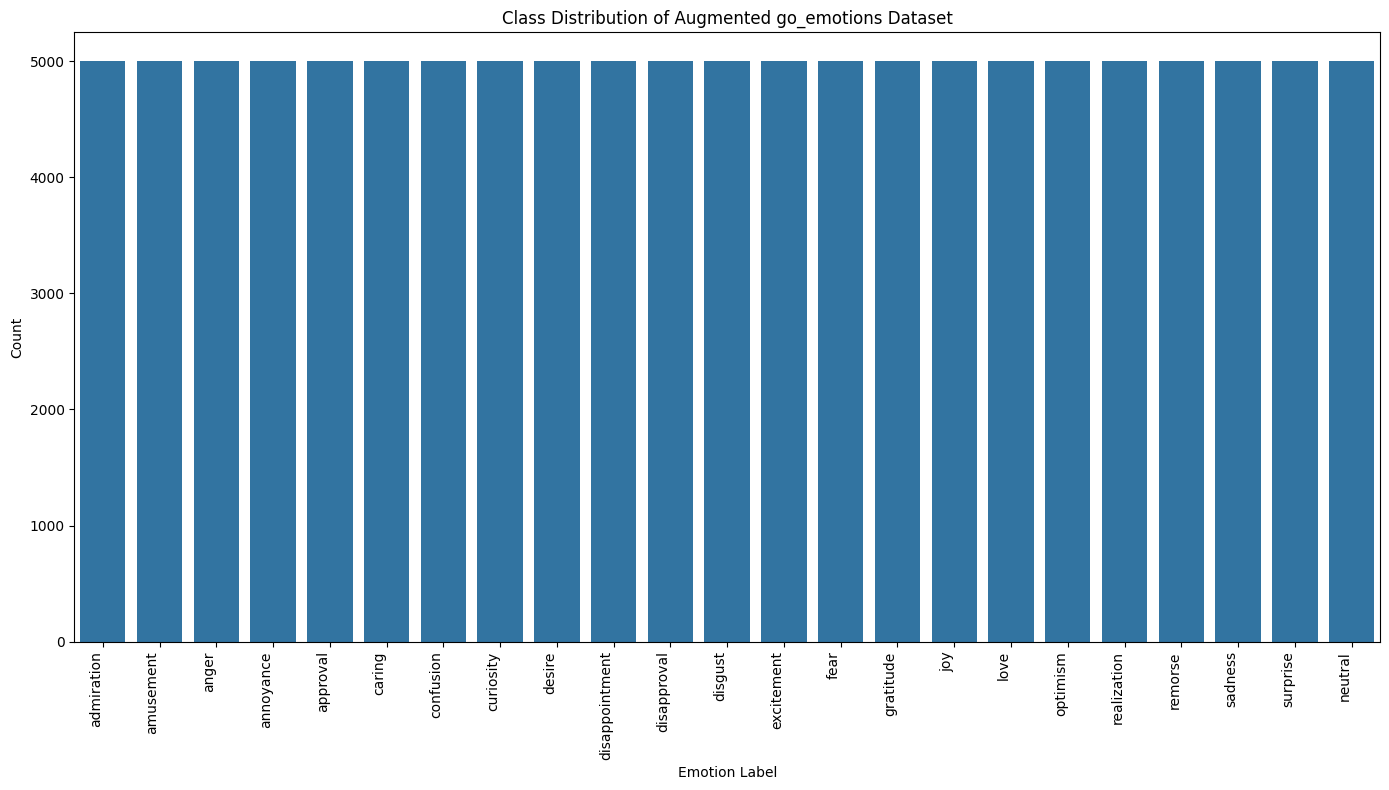


Class Distribution (Counts):
emotion
admiration        5000
amusement         5000
anger             5000
annoyance         5000
approval          5000
caring            5000
confusion         5000
curiosity         5000
desire            5000
disappointment    5000
disapproval       5000
disgust           5000
excitement        5000
fear              5000
gratitude         5000
joy               5000
love              5000
optimism          5000
realization       5000
remorse           5000
sadness           5000
surprise          5000
neutral           5000
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming augmented_df is already loaded and cleaned with 'label' column
# Assuming go_emotions_label_to_emotion mapping is available from a previous cell

# Define the go_emotions_label_to_emotion mapping here (copied for consistency)
go_emotions_label_to_emotion = {
    0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance', 4: 'approval',
    5: 'caring', 6: 'confusion', 7: 'curiosity', 8: 'desire', 9: 'disappointment',
    10: 'disapproval', 11: 'disgust', 12: 'embarrassment', 13: 'excitement',
    14: 'fear', 15: 'gratitude', 16: 'grief', 17: 'joy', 18: 'love',
    19: 'nervousness', 20: 'optimism', 21: 'pride', 22: 'realization', 23: 'relief',
    24: 'remorse', 25: 'sadness', 26: 'surprise', 27: 'neutral'
}


# Check if the necessary mapping is available
if 'go_emotions_label_to_emotion' not in locals() and 'go_emotions_label_to_emotion' not in globals():
    print("Error: go_emotions_label_to_emotion mapping not found. Cannot plot with emotion names.")
    # Fallback to numerical labels if mapping is missing
    plt.figure(figsize=(14, 8))
    sns.countplot(x='label', data=augmented_df, order=sorted(augmented_df['label'].unique()))
    plt.title('Class Distribution of Augmented go_emotions Dataset (Numerical)')
    plt.xlabel('Emotion Label (Numerical)')
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()

    print("\nClass Distribution (Counts - Numerical):")
    print(augmented_df['label'].value_counts().sort_index())

else:
    # Map the numerical labels to emotion names for plotting
    augmented_df['emotion'] = augmented_df['label'].map(go_emotions_label_to_emotion)

    # Plot the class distribution of the augmented dataset
    plt.figure(figsize=(14, 8)) # Increased figure size for 28 labels
    # Ensure the order of labels in the plot matches the order in the mapping
    # Get the unique labels from the augmented_df and sort them numerically
    present_labels_numerical = sorted(augmented_df['label'].unique())
    # Create the order for the plot using the emotion names corresponding to the sorted numerical labels
    plot_order = [go_emotions_label_to_emotion[i] for i in present_labels_numerical if i in go_emotions_label_to_emotion]

    sns.countplot(x='emotion', data=augmented_df, order=plot_order)
    plt.title('Class Distribution of Augmented go_emotions Dataset')
    plt.xlabel('Emotion Label')
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right') # Rotate labels for better readability
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()

    # Optional: Print the counts with emotion names
    print("\nClass Distribution (Counts):")
    # Use the 'emotion' column for value counts to get names
    print(augmented_df['emotion'].value_counts().sort_index(key=lambda x: x.map({v:k for k,v in go_emotions_label_to_emotion.items()}))) # Sort by original numerical index

## Split Data

### Subtask:
Split the balanced dataset into training and testing sets, ensuring the class distribution is maintained using stratification.

**Reasoning**:
Split the balanced dataset into training and testing sets while maintaining class distribution using stratification.

In [4]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = augmented_df['cleaned_text']
y = augmented_df['label']

# Split the dataset into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (92000,)
Shape of X_test: (23000,)
Shape of y_train: (92000,)
Shape of y_test: (23000,)


## Tokenize Data

### Subtask:
Tokenize the text data for the RoBERTa model.

In [5]:
from transformers import AutoTokenizer
import torch

# Load the pretrained RoBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

# Tokenize the training and testing sets
# Ensure padding and truncation are applied with a suitable maximum length
train_encodings = tokenizer(list(X_train), truncation=True, padding='max_length', max_length=128, return_tensors="pt")
test_encodings = tokenizer(list(X_test), truncation=True, padding='max_length', max_length=128, return_tensors="pt")

# Convert labels to PyTorch tensors
train_labels = torch.tensor(y_train.values)
test_labels = torch.tensor(y_test.values)

print("Tokenization complete and data converted to PyTorch tensors.")

Tokenization complete and data converted to PyTorch tensors.


## Define Dataset Class

### Subtask:
Create a custom PyTorch Dataset class to handle the tokenized data and labels.

**Reasoning**:
Define a custom PyTorch Dataset class to encapsulate the tokenized inputs and labels, making it compatible with PyTorch DataLoaders and the Hugging Face Trainer.

In [12]:
import torch
from torch.utils.data import Dataset

class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Pass the label directly as it's already a tensor
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

print("Custom Dataset class defined.")

Custom Dataset class defined.


**Reasoning**:
Import the RoBERTa tokenizer, load the pretrained tokenizer, tokenize the training and testing data with padding and truncation, and convert the tokenized outputs to PyTorch tensors.

## Load RoBERTa Model

### Subtask:
Load a pretrained RoBERTa model for sequence classification.

**Reasoning**:
Load a pretrained RoBERTa model for sequence classification and print a confirmation message.

In [7]:
from transformers import AutoModelForSequenceClassification

# Assuming augmented_df is available from previous cells and contains the 'label' column

# Get the number of unique labels in the augmented dataset
num_unique_labels = augmented_df['label'].nunique()

# Load a pretrained RoBERTa model for sequence classification with the correct number of output labels
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=num_unique_labels)

print(f"Pretrained RoBERTa model loaded successfully with {num_unique_labels} output labels.")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pretrained RoBERTa model loaded successfully with 23 output labels.


In [8]:
!pip install accelerate -U

## Train Model with Best Hyperparameters

### Subtask:
Train the RoBERTa classifier using the best hyperparameters from Optuna.

In [9]:
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification, EarlyStoppingCallback
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import numpy as np
from torch.utils.data import Dataset # Import Dataset here

# Assuming train_encodings, test_encodings, train_labels, and test_labels are available from cell fca944b1 and potentially a1364430
# Assuming augmented_df and go_emotions_label_to_emotion are available

# Define a custom PyTorch Dataset class (copied from a1364430 or 5f8164db)
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Ensure labels are numpy arrays and within valid range
        self.labels = np.array(labels, dtype=np.int64)

        # Verify labels are in valid range and remap if necessary (copied from a1364430)
        unique_labels = sorted(set(self.labels))
        if unique_labels != list(range(len(unique_labels))):
            print("WARNING: Labels are not consecutive starting from 0! Remapping...")
            label_mapping = {old: new for new, old in enumerate(unique_labels)}
            self.labels = np.array([label_mapping[label] for label in self.labels])
            print(f"Remapped labels to: {sorted(set(self.labels))}")
            # Store the mapping for potential use in compute_metrics
            self.label_mapping = label_mapping


    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# Instantiate the custom Dataset for training and testing data (copied from a1364430)
# Assuming train_encodings, test_encodings, train_labels, test_labels are available
if 'train_encodings' in globals() and 'test_encodings' in globals() and 'train_labels' in globals() and 'test_labels' in globals():
    train_dataset = TweetDataset(train_encodings, train_labels)
    test_dataset = TweetDataset(test_encodings, test_labels)
    print("Training and testing datasets instantiated.")
else:
    print("Error: Tokenized data or labels not found. Cannot instantiate datasets.")
    # You might need to add code here to load or regenerate tokenized data if not available


# Define a function to compute metrics for evaluation
def compute_metrics(p):
    preds = p.predictions.argmax(-1)

    # Get present labels from the actual data (which are now remapped 0-num_labels-1)
    # p.label_ids should already be remapped by the TweetDataset if it was instantiated correctly
    present_remapped_labels = sorted(set(p.label_ids))

    # Create emotion names - requires mapping from remapped label to original label, then to emotion name
    # Try to use the label_mapping stored in the train_dataset if available
    remapped_to_original_label = {new: old for old, new in train_dataset.label_mapping.items()} if hasattr(train_dataset, 'label_mapping') else None

    emotion_names = []
    if remapped_to_original_label and 'go_emotions_label_to_emotion' in globals():
        # Create target names based on the remapped labels (0-num_labels-1) and map back to original emotion names
        # Ensure we only map labels that are actually present in the data
        emotion_names = [go_emotions_label_to_emotion.get(remapped_to_original_label.get(i, -1), f"label_{i}") for i in sorted(remapped_to_original_label.keys()) if i in present_remapped_labels]
        # If the above list is empty or incomplete, fall back to numerical names
        if not emotion_names or len(emotion_names) != len(present_remapped_labels):
             emotion_names = [str(i) for i in present_remapped_labels]
    else:
        # Fallback to using remapped numerical labels as names
        emotion_names = [str(i) for i in present_remapped_labels]


    # Ensure labels and predictions are compatible. Both should be in the remapped range (0-num_labels-1).
    # p.label_ids should already be remapped by the TweetDataset.
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='weighted', zero_division=0)
    acc = accuracy_score(p.label_ids, preds)
    # Generate classification report as a dictionary
    report = classification_report(p.label_ids, preds, target_names=emotion_names, output_dict=True, zero_division=0)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'report': report # Include the classification report dictionary
    }


# Updated TrainingArguments for better generalization
training_args = TrainingArguments(
    output_dir='./results_best_run',
    num_train_epochs=3, # Use best epoch count, default to 3
    learning_rate=5e-5, # Use best learning rate, default to 5e-5
    per_device_train_batch_size=32, # Use best batch size, default to 32
    per_device_eval_batch_size=32, # Use best batch size, default to 32
    gradient_accumulation_steps=2,      # effective batch doubling
    warmup_ratio=0.1,                   # 10% warmup
    weight_decay=0.01,
    logging_dir='./logs_best_run',
    logging_steps=500,
    eval_strategy='steps',        # evaluate during training
    eval_steps=1000,                     # every 100 steps
    save_strategy='steps',
    save_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    group_by_length=True,
    report_to="none",
    save_total_limit=3,
    seed=42,
    dataloader_pin_memory=False, # Disable pin_memory if CUDA issues persist
    remove_unused_columns=True # Remove unused columns from dataset before passing to model
)

# Load model with the correct number of labels (23)
# Assuming augmented_df is available to get the number of unique labels
if 'augmented_df' in globals():
    num_unique_labels = augmented_df['label'].nunique()
    model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=num_unique_labels)
else:
    print("Error: augmented_df not found. Cannot determine number of unique labels. Loading model with default 23 labels.")
    model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=23)


# Trainer with early stopping on eval_f1
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Corrected typo: early_stopping_patience
)

print("Starting training with improved settings...")
trainer.train()
print("Training complete.")

Remapped labels to: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]
Remapped labels to: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]
Training and testing datasets instantiated.


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training with improved settings...


C:\Users\adria\AppData\Local\Temp\ipykernel_8032\2052932081.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Report
1000,0.642200,0.596954,0.820348,0.832652,0.820348,0.822759,"{'0': {'precision': 0.7266187050359713, 'recall': 0.707, 'f1-score': 0.7166751140395337, 'support': 1000.0}, '1': {'precision': 0.8434065934065934, 'recall': 0.921, 'f1-score': 0.8804971319311663, 'support': 1000.0}, '2': {'precision': 0.8025291828793775, 'recall': 0.825, 'f1-score': 0.8136094674556213, 'support': 1000.0}, '3': {'precision': 0.8507223113964687, 'recall': 0.53, 'f1-score': 0.6531115218730745, 'support': 1000.0}, '4': {'precision': 0.6116970278044104, 'recall': 0.638, 'f1-score': 0.6245717082721488, 'support': 1000.0}, '5': {'precision': 0.8467078189300411, 'recall': 0.823, 'f1-score': 0.834685598377282, 'support': 1000.0}, '6': {'precision': 0.9756410256410256, 'recall': 0.761, 'f1-score': 0.8550561797752809, 'support': 1000.0}, '7': {'precision': 0.6816770186335404, 'recall': 0.878, 'f1-score': 0.7674825174825175, 'support': 1000.0}, '8': {'precision': 0.913894324853229, 'recall': 0.934, 'f1-score': 0.923837784371909, 'support': 1000.0}, '9': {'precision': 0.8229376257545271, 'recall': 0.818, 'f1-score': 0.8204613841524574, 'support': 1000.0}, '10': {'precision': 0.7548125633232016, 'recall': 0.745, 'f1-score': 0.7498741821841973, 'support': 1000.0}, '11': {'precision': 0.9325842696629213, 'recall': 0.913, 'f1-score': 0.922688226376958, 'support': 1000.0}, '12': {'precision': 0.9659477866061293, 'recall': 0.851, 'f1-score': 0.9048378522062732, 'support': 1000.0}, '13': {'precision': 0.9396039603960396, 'recall': 0.949, 'f1-score': 0.9442786069651742, 'support': 1000.0}, '14': {'precision': 0.8656575212866604, 'recall': 0.915, 'f1-score': 0.8896451142440447, 'support': 1000.0}, '15': {'precision': 0.8707070707070707, 'recall': 0.862, 'f1-score': 0.8663316582914573, 'support': 1000.0}, '16': {'precision': 0.8520220588235294, 'recall': 0.927, 'f1-score': 0.8879310344827587, 'support': 1000.0}, '17': {'precision': 0.933695652173913, 'recall': 0.859, 'f1-score': 0.8947916666666667, 'support': 1000.0}, '18': {'precision': 0.9163135593220338, 'recall': 0.865, 'f1-score': 0.8899176954732511, 'support': 1000.0}, '19': {'precision': 0.907735321528425, 'recall': 0.974, 'f1-score': 0.9397009165460685, 'support': 1000.0}, '20': {'precision': 0.8766094420600858, 'recall': 0.817, 'f1-score': 0.8457556935817805, 'support': 1000.0}, '21': {'precision': 0.9025906735751296, 'recall': 0.871, 'f1-score': 0.8865139949109415, 'support': 1000.0}, '22': {'precision': 0.35688005886681384, 'recall': 0.485, 'f1-score': 0.4111911827045358, 'support': 1000.0}, 'accuracy': 0.8203478260869566, 'macro avg': {'precision': 0.8326518075072669, 'recall': 0.8203478260869564, 'f1-score': 0.8227585318419608, 'support': 23000.0}, 'weighted avg': {'precision': 0.8326518075072669, 'recall': 0.8203478260869566, 'f1-score': 0.8227585318419608, 'support': 23000.0}}"
2000,0.502800,0.549500,0.831304,0.829450,0.831304,0.829167,"{'0': {'precision': 0.696969696969697, 'recall': 0.759, 'f1-score': 0.726663475347056, 'support': 1000.0}, '1': {'precision': 0.8361531611754229, 'recall': 0.939, 'f1-score': 0.8845972680169572, 'support': 1000.0}, '2': {'precision': 0.8180914512922465, 'recall': 0.823, 'f1-score': 0.8205383848454636, 'support': 1000.0}, '3': {'precision': 0.6289370078740157, 'recall': 0.639, 'f1-score': 0.6339285714285714, 'support': 1000.0}, '4': {'precision': 0.695067264573991, 'recall': 0.62, 'f1-score': 0.6553911205073996, 'support': 1000.0}, '5': {'precision': 0.8575851393188855, 'recall': 0.831, 'f1-score': 0.8440832910106653, 'support': 1000.0}, '6': {'precision': 0.9240362811791383, 'recall': 0.815, 'f1-score': 0.8660998937300743, 'support': 1000.0}, '7': {'precision': 0.7239316239316239, 'recall': 0.847, 'f1-score': 0.7806451612903226, 'support': 1000.0}, '8': {'precision': 0.9356136820925554, 'recall': 0.93, 'f1-score': 0.9327983951855566, 'support': 1000.0}, '9': {'precision': 0.8353909465020576, 'recall': 0.81

C:\Users\adria\AppData\Local\Temp\ipykernel_8032\2052932081.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_8032\2052932081.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_8032\2052932081.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in s

Training complete.


## Save the Fine-tuned Model

### Subtask:
Save the fine-tuned RoBERTa model and tokenizer to the specified local path.

**Reasoning**:
Define the local save path, create the directory if it doesn't exist, save the model using the `trainer.save_model()` method, save the tokenizer using the `tokenizer.save_pretrained()` method, and print a confirmation message.

In [11]:
import os

# Define the local path to save the model
save_path_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\roberta_classifieraugmented"

# Create the directory if it doesn't exist
os.makedirs(save_path_local, exist_ok=True)

# Save the model using the trainer
trainer.save_model(save_path_local)

# Save the tokenizer (assuming 'tokenizer' object is still available from tokenization step)
tokenizer.save_pretrained(save_path_local)

print(f"RoBERTa model and tokenizer saved to {save_path_local}")

RoBERTa model and tokenizer saved to C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\roberta_classifieraugmented


## Generate Classification Report and Confusion Matrix

### Subtask:
Generate a classification report and confusion matrix for the trained RoBERTa model on the test set.

**Reasoning**:
Use the trained `trainer` object to get predictions on the `test_dataset`, then use `sklearn.metrics.classification_report` and `sklearn.metrics.confusion_matrix` to generate and print the report and matrix.

In [12]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Define the local path where the model and tokenizer are saved
load_path_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\roberta_classifieraugmented"

# Load the trained model and tokenizer
loaded_model = AutoModelForSequenceClassification.from_pretrained(load_path_local)
loaded_tokenizer = AutoTokenizer.from_pretrained(load_path_local)

print(f"Model and tokenizer loaded from {load_path_local}")

Model and tokenizer loaded from C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\roberta_classifieraugmented


C:\Users\adria\AppData\Local\Temp\ipykernel_8032\2052932081.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Classification Report:
                precision    recall  f1-score   support

    admiration       0.72      0.76      0.74      1000
     amusement       0.87      0.92      0.90      1000
         anger       0.81      0.84      0.83      1000
     annoyance       0.65      0.63      0.64      1000
      approval       0.65      0.63      0.64      1000
        caring       0.85      0.85      0.85      1000
     confusion       0.91      0.84      0.87      1000
     curiosity       0.73      0.86      0.79      1000
        desire       0.93      0.93      0.93      1000
disappointment       0.82      0.83      0.83      1000
   disapproval       0.76      0.78      0.77      1000
       disgust       0.90      0.93      0.92      1000
    excitement       0.90      0.90      0.90      1000
          fear       0.91      0.96      0.93      1000
     gratitude       0.90      0.90      0.90      1000
           joy       0.88      0.88      0.88      1000
          love       0.8

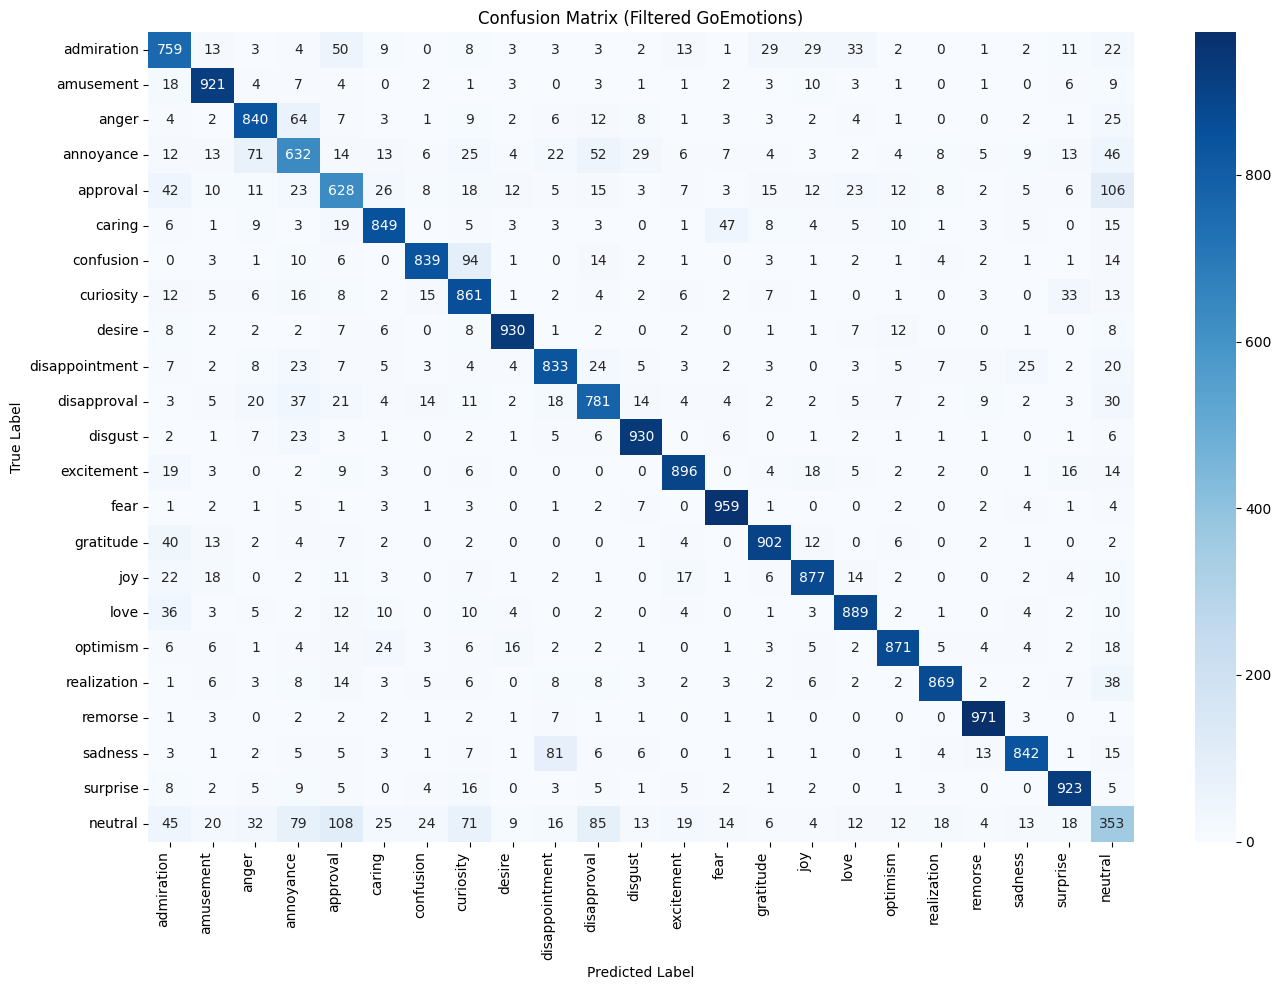

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

# Ensure the loaded model is in evaluation mode and on the correct device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model.to(device)
loaded_model.eval()

# Create a DataLoader for the test dataset
test_dataloader = DataLoader(test_dataset, batch_size=32)

predictions = []
true_labels = []

# Get predictions on the test dataset using the loaded model
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = loaded_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Build mapping from remapped label index -> original label
# Assuming test_dataset.label_mapping exists: original_label -> remapped_index
remap = test_dataset.label_mapping  # dict: original -> remapped
# Invert mapping: remapped -> original
inv_map = {v: k for k, v in remap.items()}

# Define the go_emotions_label_to_emotion mapping here
go_emotions_label_to_emotion = {
    0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance', 4: 'approval',
    5: 'caring', 6: 'confusion', 7: 'curiosity', 8: 'desire', 9: 'disappointment',
    10: 'disapproval', 11: 'disgust', 12: 'embarrassment', 13: 'excitement',
    14: 'fear', 15: 'gratitude', 16: 'grief', 17: 'joy', 18: 'love',
    19: 'nervousness', 20: 'optimism', 21: 'pride', 22: 'realization', 23: 'relief',
    24: 'remorse', 25: 'sadness', 26: 'surprise', 27: 'neutral'
}

# Sorted list of remapped labels present
remapped_labels_present = sorted(set(true_labels))

# Map each remapped index to original label then to emotion name
emotion_names = []
for rem in remapped_labels_present:
    orig = inv_map[rem]
    emotion_name = go_emotions_label_to_emotion.get(orig, f"label_{orig}")
    emotion_names.append(emotion_name)

# Classification report
print("Classification Report:")
print(classification_report(
    true_labels,
    predictions,
    labels=remapped_labels_present,
    target_names=emotion_names,
    zero_division=0
))

# Confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions, labels=remapped_labels_present)

# Plot confusion matrix
plt.figure(figsize=(14, 10))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Filtered GoEmotions)')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Roberta og dataset


## Load the original dataset

### Subtask:
Load the "cardiffnlp/tweet_eval" dataset with the "sentiment" configuration.


**Reasoning**:
Load the specified dataset and print its structure to understand its composition.



In [1]:
from datasets import load_dataset

# Load the "go_emotions" dataset
original_dataset = load_dataset("go_emotions")

# Print the structure of the loaded dataset
print(original_dataset)

# Define the list of labels that were balanced to 5000 samples in the augmented dataset
# This list is based on the output from cell _SmIH0Xir6uA
# Note: The labels here correspond to the original go_emotions labels, not the remapped ones.
balanced_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 20, 22, 24, 25, 26, 27]

# Filter the original dataset to include only examples where the *first* label is in balanced_labels
# go_emotions has a list of labels, so we check the first one as done in previous cleaning steps.
original_dataset_filtered = original_dataset.filter(lambda example: example['labels'] and example['labels'][0] in balanced_labels)

print(f"\nOriginal dataset filtered to include labels (based on the first label): {balanced_labels}")
print(original_dataset_filtered)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Original dataset filtered to include labels (based on the first label): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 20, 22, 24, 25, 26, 27]
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 42839
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5360
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5360
    })
})


## Clean and preprocess data

### Subtask:
Clean and preprocess the text data from the original dataset by removing mentions, URLs, and punctuation, and handle any missing values.


**Reasoning**:
Concatenate the dataset splits, convert to pandas, handle missing values, define and apply the cleaning function, and display the results and shape.



In [2]:
import re
import pandas as pd
from datasets import concatenate_datasets

# Concatenate the dataset splits from the filtered dataset
combined_original = concatenate_datasets([
    original_dataset_filtered["train"],
    original_dataset_filtered["validation"],
    original_dataset_filtered["test"]
])

# Convert to pandas DataFrame
original_df = pd.DataFrame(combined_original)

# Check for missing values before cleaning
print("Missing values before cleaning:")
print(original_df.isnull().sum())

# Handle missing values: Drop rows where 'text' is missing
original_df.dropna(subset=['text'], inplace=True)

# Extract the first label from the 'labels' list and create a new 'label' column
original_df['label'] = original_df['labels'].apply(lambda x: x[0] if x else None)

# Drop rows where the new 'label' is None (if any after processing the list)
original_df.dropna(subset=['label'], inplace=True)


# Define the cleaning function (copied from cell f7b15f04 for consistency)
# Map for all 28 go_emotions dataset labels (included here as requested)
EMOTION_MAP = {
    0: "[ADMIRATION]", 1: "[AMUSEMENT]", 2: "[ANGER]", 3: "[ANNOYANCE]", 4: "[APPROVAL]",
    5: "[CARING]", 6: "[CONFUSION]", 7: "[CURIOUSITY]", 8: "[DESIRE]", 9: "[DISAPPOINTMENT]",
    10: "[DISAPPROVAL]", 11: "[DISGUST]", 12: "[EMBARRASSMENT]", 13: "[EXCITEMENT]",
    14: "[FEAR]", 15: "[GRATITUDE]", 16: "[GRIEF]", 17: "[JOY]", 18: "[LOVE]",
    19: "[NERVOUSNESS]", 20: "[OPTIMISM]", 21: "[PRIDE]", 22: "[REALIZATION]", 23: "[RELIEF]",
    24: "[REMORSE]", 25: "[SADNESS]", 26: "[SURPRISE]", 27: "[NEUTRAL]"
}


def clean_text_original(text):
    # Check if the input is a string before applying string methods
    if not isinstance(text, str):
        return "" # Return an empty string for non-string inputs (like NaN)

    cleaned_text = text # Start with the original text

    # Create a regex pattern to match any of the 28 emotion tokens from EMOTION_MAP
    # Remove emotion prefix tokens *before* converting to lowercase
    if 'EMOTION_MAP' in globals():
        # Escape each token to handle special regex characters
        emotion_tokens_pattern = '|'.join(re.escape(token) for token in EMOTION_MAP.values())
        # Remove emotion prefix tokens at the beginning of the string, followed by any whitespace or punctuation
        # Relaxing the word boundary \b slightly and being more explicit about trailing characters
        cleaned_text = re.sub(rf'^\s*({emotion_tokens_pattern})[\s\W]*', '', cleaned_text)
        # Also remove tokens that might appear elsewhere in the text, followed by whitespace or punctuation
        cleaned_text = re.sub(rf'[\s\W]*({emotion_tokens_pattern})[\s\W]*', ' ', cleaned_text).strip()


    # Convert to lowercase
    cleaned_text = cleaned_text.lower()
    # Remove mentions (@user) and URLs (http\S+)
    cleaned_text = re.sub(r'(@\w+|http\S+)', '', cleaned_text)
    # Remove punctuation (keeping spaces) - keeping basic punctuation .,!?-
    cleaned_text = re.sub(r'[^\w\s.,!?-]', '', cleaned_text) # Added common punctuation
     # Remove extra spaces around punctuation
    cleaned_text = re.sub(r'\s*([.,!?-])\s*', r'\1 ', cleaned_text).strip()
    # Replace multiple spaces with a single space and strip leading/trailing whitespace
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    return cleaned_text


# Apply the cleaning function to the 'text' column and create 'cleaned_text'
original_df['cleaned_text'] = original_df['text'].apply(clean_text_original)

# Display the first few rows, including the new 'label' and 'cleaned_text' columns
display(original_df[['text', 'cleaned_text', 'label']].head())

# Print the shape after cleaning and processing labels
print(f"Shape of the original DataFrame after cleaning and processing labels: {original_df.shape}")

Missing values before cleaning:
text      0
labels    0
id        0
dtype: int64


,text,cleaned_text,label
0,My favourite food is anything I didn't have to...,my favourite food is anything i didnt have to ...,27
1,"Now if he does off himself, everyone will thin...","now if he does off himself, everyone will thin...",27
2,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,2
3,To make her feel threatened,to make her feel threatened,14
4,Dirty Southern Wankers,dirty southern wankers,3


Shape of the original DataFrame after cleaning and processing labels: (53559, 5)


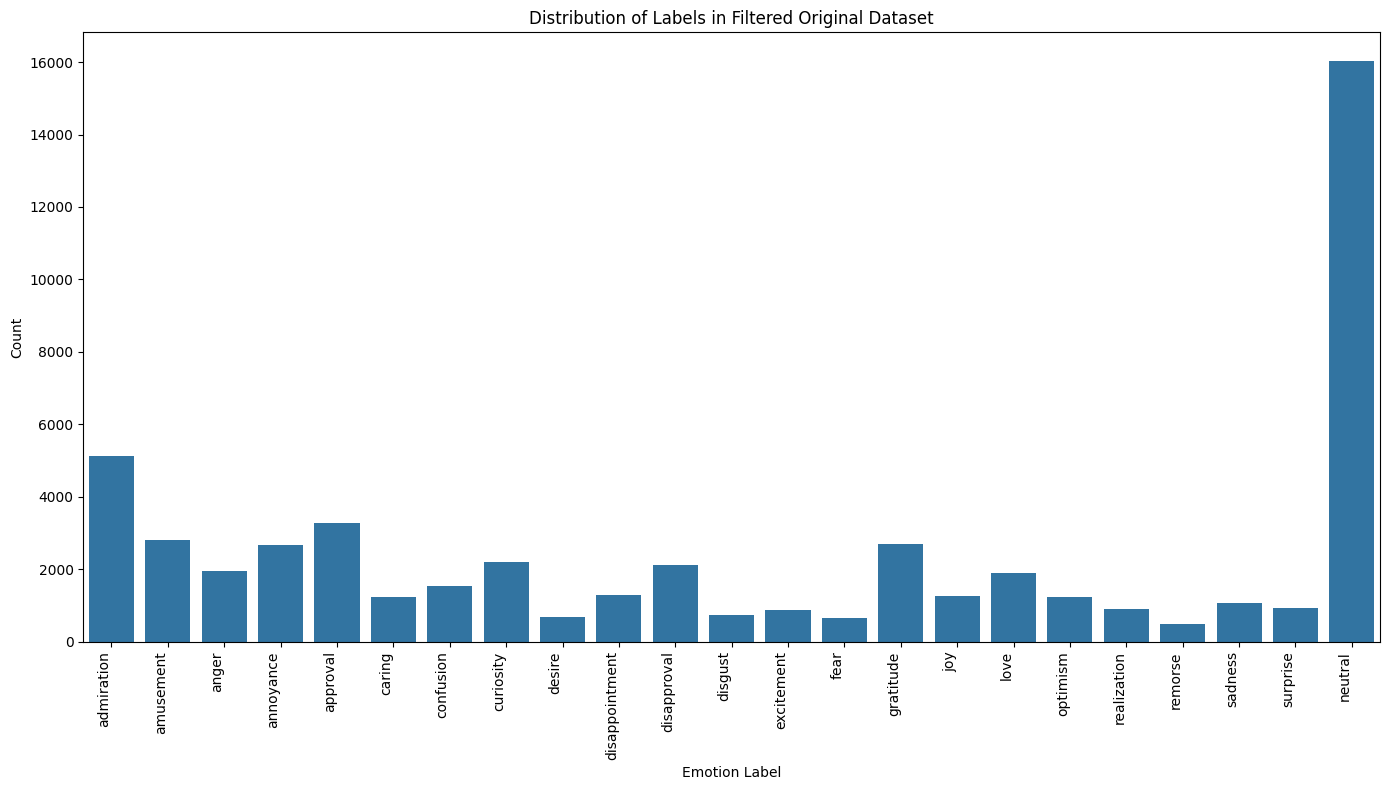


Distribution of Labels (Counts):
label
0      5122
1      2793
2      1936
3      2671
4      3269
5      1218
6      1543
7      2210
8       681
9      1284
10     2117
11      738
13      862
14      658
15     2681
17     1250
18     1883
20     1227
22      893
24      497
25     1067
26      938
27    16021
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming original_df is available from cell 706c5ea7 and contains the 'label' column

# Get the value counts of the 'label' column
label_counts_original = original_df['label'].value_counts().sort_index()

# Define the go_emotions_label_to_emotion mapping (copied for consistency)
go_emotions_label_to_emotion = {
    0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance', 4: 'approval',
    5: 'caring', 6: 'confusion', 7: 'curiosity', 8: 'desire', 9: 'disappointment',
    10: 'disapproval', 11: 'disgust', 12: 'embarrassment', 13: 'excitement',
    14: 'fear', 15: 'gratitude', 16: 'grief', 17: 'joy', 18: 'love',
    19: 'nervousness', 20: 'optimism', 21: 'pride', 22: 'realization', 23: 'relief',
    24: 'remorse', 25: 'sadness', 26: 'surprise', 27: 'neutral'
}

# Map numerical labels to emotion names for plotting
label_counts_original_mapped = label_counts_original.rename(index=go_emotions_label_to_emotion)


# Plot the distribution of the 'label' column
plt.figure(figsize=(14, 8)) # Increased figure size for 23 labels
sns.barplot(x=label_counts_original_mapped.index, y=label_counts_original_mapped.values)
plt.title('Distribution of Labels in Filtered Original Dataset')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

print("\nDistribution of Labels (Counts):")
print(label_counts_original)

## Split data

### Subtask:
Split the cleaned original dataset into training and testing sets.


**Reasoning**:
Split the cleaned original dataset into training and testing sets.



In [4]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = original_df['cleaned_text']
y = original_df['label']

# Split the dataset into training and testing sets
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print(f"Shape of X_train_original: {X_train_original.shape}")
print(f"Shape of X_test_original: {X_test_original.shape}")
print(f"Shape of y_train_original: {y_train_original.shape}")
print(f"Shape of y_test_original: {y_test_original.shape}")

Shape of X_train_original: (42847,)
Shape of X_test_original: (10712,)
Shape of y_train_original: (42847,)
Shape of y_test_original: (10712,)


## Tokenize data

### Subtask:
Tokenize the text data using the RoBERTa tokenizer.


**Reasoning**:
Import the necessary tokenizer, load it, and tokenize the training and testing data, then convert labels to tensors.



In [5]:
from transformers import AutoTokenizer
import torch
import numpy as np # Import numpy

# Load the pretrained RoBERTa tokenizer
tokenizer_original = AutoTokenizer.from_pretrained('roberta-base')

# Tokenize the training and testing sets
# Ensure padding and truncation are applied with a suitable maximum length
train_encodings_original = tokenizer_original(list(X_train_original), truncation=True, padding='max_length', max_length=128, return_tensors="pt")
test_encodings_original = tokenizer_original(list(X_test_original), truncation=True, padding='max_length', max_length=128, return_tensors="pt")

# Convert labels to numpy arrays for consistent handling
train_labels_original_np = np.array(y_train_original.values, dtype=np.int64)
test_labels_original_np = np.array(y_test_original.values, dtype=np.int64)

# Get unique labels to create a remapping dictionary
unique_labels_original = sorted(list(set(np.concatenate((train_labels_original_np, test_labels_original_np)))))
label_mapping_original = {old: new for new, old in enumerate(unique_labels_original)}

print(f"\nOriginal unique labels: {sorted(set(train_labels_original_np.tolist()))}")
print(f"Label mapping: {label_mapping_original}")

# Apply the remapping to the labels
train_labels_original_remapped_np = np.array([label_mapping_original[label] for label in train_labels_original_np])
test_labels_original_remapped_np = np.array([label_mapping_original[label] for label in test_labels_original_np])

# Convert remapped labels to PyTorch tensors
train_labels_original_tensor = torch.tensor(train_labels_original_remapped_np, dtype=torch.long)
test_labels_original_tensor = torch.tensor(test_labels_original_remapped_np, dtype=torch.long)


print(f"\nUnique remapped labels in original train set: {sorted(set(train_labels_original_remapped_np.tolist()))}")
print(f"Unique remapped labels in original test set: {sorted(set(test_labels_original_remapped_np.tolist()))}")


print("\nTokenization complete and data converted to PyTorch tensors with remapped labels.")


Original unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 20, 22, 24, 25, 26, 27]
Label mapping: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7, np.int64(8): 8, np.int64(9): 9, np.int64(10): 10, np.int64(11): 11, np.int64(13): 12, np.int64(14): 13, np.int64(15): 14, np.int64(17): 15, np.int64(18): 16, np.int64(20): 17, np.int64(22): 18, np.int64(24): 19, np.int64(25): 20, np.int64(26): 21, np.int64(27): 22}

Unique remapped labels in original train set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Unique remapped labels in original test set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

Tokenization complete and data converted to PyTorch tensors with remapped labels.


## Define dataset class

### Subtask:
Create a custom PyTorch Dataset class to handle the tokenized data and labels.


In [6]:
import torch
from torch.utils.data import Dataset

class TweetDatasetOriginal(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

print("Custom Dataset class defined.")

Custom Dataset class defined.


In [7]:
# Instantiate the custom Dataset for original training and testing data
# Pass the remapped label tensors from d30fa812
if 'train_encodings_original' in globals() and 'test_encodings_original' in globals() and 'train_labels_original_tensor' in globals() and 'test_labels_original_tensor' in globals():
    train_dataset_original = TweetDatasetOriginal(train_encodings_original, train_labels_original_tensor)
    test_dataset_original = TweetDatasetOriginal(test_encodings_original, test_labels_original_tensor)
    print("Original training and testing datasets instantiated with remapped label tensors.")
else:
    print("Error: Tokenized data or remapped label tensors not found. Cannot instantiate datasets.")
    # Provide guidance on which cells to run if data is missing
    missing_vars = [var_name for var_name in ['train_encodings_original', 'test_encodings_original', 'train_labels_original_tensor', 'test_labels_original_tensor'] if var_name not in globals()]
    if missing_vars:
        print(f"Missing variables: {missing_vars}. Please ensure cell d30fa812 was run successfully.")

Original training and testing datasets instantiated with remapped label tensors.


**Reasoning**:
Define a custom PyTorch Dataset class to encapsulate the tokenized inputs and labels, making it compatible with PyTorch DataLoaders and the Hugging Face Trainer.



## Load roberta model

### Subtask:
Load a pretrained RoBERTa model for sequence classification.


**Reasoning**:
Load a pretrained RoBERTa model for sequence classification and print a confirmation message.



In [8]:
from transformers import AutoModelForSequenceClassification

# Assuming original_df or train_labels_original is available to get the number of unique labels
# Based on the filtering and balancing done earlier, there are 23 unique labels.
num_unique_labels_original = 23 # Explicitly setting to 23 based on previous filtering/balancing

# Load a pretrained RoBERTa model for sequence classification with the correct number of output labels
model_original = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=num_unique_labels_original)

print(f"Pretrained RoBERTa model loaded successfully with {num_unique_labels_original} output labels.")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pretrained RoBERTa model loaded successfully with 23 output labels.


**Reasoning**:
Instantiate the custom dataset class for the original training and testing data.



**Reasoning**:
Define the training arguments and initialize the Trainer with the original datasets and model, then start training.



In [9]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import numpy as np
import torch
from torch.utils.data import Dataset

# Define a function to compute metrics for evaluation
def compute_metrics_original(p):
    preds = p.predictions.argmax(-1)

    # p.label_ids should now contain the remapped labels (0 to num_labels-1)
    true_labels_remapped = p.label_ids
    predictions_remapped = preds

    # Add print statements for debugging
    print("\n--- Inside compute_metrics_original ---")
    print(f"Shape of true_labels_remapped: {true_labels_remapped.shape}")
    print(f"Shape of predictions_remapped: {predictions_remapped.shape}")
    print(f"Unique true_labels_remapped: {sorted(set(true_labels_remapped.tolist()))}")
    print(f"Min true_labels_remapped: {np.min(true_labels_remapped)}")
    print(f"Max true_labels_remapped: {np.max(true_labels_remapped)}")
    print(f"Unique predictions_remapped: {sorted(set(predictions_remapped.tolist()))}")
    print(f"Min predictions_remapped: {np.min(predictions_remapped)}")
    print(f"Max predictions_remapped: {np.max(predictions_remapped)}")
    print("---------------------------------------")

    # Explicitly check label range
    num_unique_labels_original = 23 # Based on previous filtering/balancing
    if np.min(true_labels_remapped) < 0 or np.max(true_labels_remapped) >= num_unique_labels_original:
        print(f"ERROR: true_labels_remapped contain values outside expected range [0, {num_unique_labels_original-1}]!")
    if np.min(predictions_remapped) < 0 or np.max(predictions_remapped) >= num_unique_labels_original:
        print(f"ERROR: predictions_remapped contain values outside expected range [0, {num_unique_labels_original-1}]!")


    present_remapped_labels = sorted(set(true_labels_remapped))

    # Define the go_emotions_label_to_emotion mapping here (copied for consistency)
    go_emotions_label_to_emotion = {
        0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance', 4: 'approval',
        5: 'caring', 6: 'confusion', 7: 'curiosity', 8: 'desire', 9: 'disappointment',
        10: 'disapproval', 11: 'disgust', 12: 'embarrassment', 13: 'excitement',
        14: 'fear', 15: 'gratitude', 16: 'grief', 17: 'joy', 18: 'love',
        19: 'nervousness', 20: 'optimism', 21: 'pride', 22: 'realization', 23: 'relief',
        24: 'remorse', 25: 'sadness', 26: 'surprise', 27: 'neutral'
    }

    # Build mapping from remapped label index -> original label using the mapping from d30fa812
    # Assuming label_mapping_original is available in the global scope from cell d30fa812
    if 'label_mapping_original' in globals():
        remap = label_mapping_original  # dict: original -> remapped
        # Invert mapping: remapped -> original
        inv_map = {v: k for k, v in remap.items()}
        # Map each remapped index to original label then to emotion name
        emotion_names = []
        for rem in present_remapped_labels:
             orig = inv_map.get(rem, -1) # Use .get with a default for safety
             emotion_name = go_emotions_label_to_emotion.get(orig, f"label_{orig}")
             emotion_names.append(emotion_name)

        # If the generated emotion_names list is empty or its length doesn't match the number of unique remapped labels,
        # fall back to using remapped numerical labels as names.
        if not emotion_names or len(emotion_names) != len(present_remapped_labels):
             print("Warning: Could not generate emotion names, falling back to numerical labels.")
             emotion_names = [str(i) for i in present_remapped_labels]
    else:
        print("Error: label_mapping_original not found. Cannot map to emotion names. Falling back to numerical labels.")
        # Fallback to using remapped numerical labels as names
        emotion_names = [str(i) for i in present_remapped_labels]


    precision, recall, f1, _ = precision_recall_fscore_support(true_labels_remapped, predictions_remapped, average='weighted', zero_division=0)
    acc = accuracy_score(true_labels_remapped, predictions_remapped)

    # Generate classification report as a dictionary
    # Ensure the labels argument for classification_report is the list of *remapped* labels present
    report = classification_report(
        true_labels_remapped,
        predictions_remapped,
        labels=present_remapped_labels,
        target_names=emotion_names,
        output_dict=True,
        zero_division=0
    )

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'report': report # Include the classification report dictionary
    }

# Define training arguments
training_args_original = TrainingArguments(
    output_dir='./results_original',          # output directory
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=32,   # batch size per device during training
    per_device_eval_batch_size=32,   # batch size per device during evaluation
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs_original',            # directory for storing logs
    logging_steps=100,               # log every 100 steps
    eval_strategy='epoch',    # evaluate at the end of each epoch
    save_strategy='epoch',          # save at the end of each epoch
    load_best_model_at_end=True,     # load the best model based on eval_loss at the end of training
    metric_for_best_model='eval_loss', # metric to monitor for early stopping
    greater_is_better=False,         # for eval_loss, smaller is better
    fp16=torch.cuda.is_available(), # Enable mixed precision if CUDA is available
    report_to="none", # Disable reporting to Weights & Biases
    remove_unused_columns=False # Keep unused columns for dataset consistency if needed
)

# Assuming model_original and train_dataset_original, test_dataset_original are available
# Initialize the Trainer
trainer_original = Trainer(
    model=model_original,
    args=training_args_original,
    train_dataset=train_dataset_original,
    eval_dataset=test_dataset_original,
    compute_metrics=compute_metrics_original
)

print("Starting training of the original model with updated metrics...")
# Start training
trainer_original.train()
print("Training of the original model complete.")

Starting training of the original model with updated metrics...


C:\Users\adria\AppData\Local\Temp\ipykernel_15236\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_15236\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Report
1,1.445400,1.359017,0.573562,0.576730,0.573562,0.557344,"{'admiration': {'precision': 0.7437934458788481, 'recall': 0.6948051948051948, 'f1-score': 0.7184652278177458, 'support': 1078.0}, 'amusement': {'precision': 0.717425431711146, 'recall': 0.8354661791590493, 'f1-score': 0.7719594594594594, 'support': 547.0}, 'anger': {'precision': 0.505586592178771, 'recall': 0.48655913978494625, 'f1-score': 0.4958904109589041, 'support': 372.0}, 'annoyance': {'precision': 0.3548387096774194, 'recall': 0.32897196261682243, 'f1-score': 0.3414161008729389, 'support': 535.0}, 'approval': {'precision': 0.5240793201133145, 'recall': 0.2850539291217257, 'f1-score': 0.36926147704590817, 'support': 649.0}, 'caring': {'precision': 0.3039772727272727, 'recall': 0.5047169811320755, 'f1-score': 0.37943262411347517, 'support': 212.0}, 'confusion': {'precision': 0.5714285714285714, 'recall': 0.2828282828282828, 'f1-score': 0.3783783783783784, 'support': 297.0}, 'curiosity': {'precision': 0.4167794316644114, 'recall': 0.6637931034482759, 'f1-score': 0.5120532003325021, 'support': 464.0}, 'desire': {'precision': 0.4689265536723164, 'recall': 0.5724137931034483, 'f1-score': 0.515527950310559, 'support': 145.0}, 'disappointment': {'precision': 0.4942528735632184, 'recall': 0.16412213740458015, 'f1-score': 0.24641833810888253, 'support': 262.0}, 'disapproval': {'precision': 0.4212121212121212, 'recall': 0.3270588235294118, 'f1-score': 0.36821192052980134, 'support': 425.0}, 'disgust': {'precision': 0.39603960396039606, 'recall': 0.5128205128205128, 'f1-score': 0.44692737430167595, 'support': 156.0}, 'excitement': {'precision': 0.3979591836734694, 'recall': 0.2254335260115607, 'f1-score': 0.2878228782287823, 'support': 173.0}, 'fear': {'precision': 0.6015037593984962, 'recall': 0.6201550387596899, 'f1-score': 0.6106870229007634, 'support': 129.0}, 'gratitude': {'precision': 0.7457098283931357, 'recall': 0.9104761904761904, 'f1-score': 0.8198970840480274, 'support': 525.0}, 'joy': {'precision': 0.5665024630541872, 'recall': 0.45634920634920634, 'f1-score': 0.5054945054945055, 'support': 252.0}, 'love': {'precision': 0.5696, 'recall': 0.9175257731958762, 'f1-score': 0.702862783810464, 'support': 388.0}, 'optimism': {'precision': 0.7619047619047619, 'recall': 0.18604651162790697, 'f1-score': 0.29906542056074764, 'support': 258.0}, 'realization': {'precision': 0.5476190476190477, 'recall': 0.13855421686746988, 'f1-score': 0.22115384615384615, 'support': 166.0}, 'remorse': {'precision': 0.5251798561151079, 'recall': 0.8690476190476191, 'f1-score': 0.6547085201793722, 'support': 84.0}, 'sadness': {'precision': 0.5813953488372093, 'recall': 0.3694581280788177, 'f1-score': 0.45180722891566266, 'support': 203.0}, 'surprise': {'precision': 0.5021645021645021, 'recall': 0.6073298429319371, 'f1-score': 0.5497630331753555, 'support': 191.0}, 'neutral': {'precision': 0.6099914845302299, 'recall': 0.6713527022805373, 'f1-score': 0.6392028554431886, 'support': 3201.0}, 'accuracy': 0.573562359970127, 'macro avg': {'precision': 0.535994354933824, 'recall': 0.505666904147006, 'f1-score': 0.4907133757017803, 'support': 10712.0}, 'weighted avg': {'precision': 0.5767295765189602, 'recall': 0.573562359970127, 'f1-score': 0.5573441717005462, 'support': 10712.0}}"
2,1.207700,1.328721,0.579164,0.571485,0.579164,0.566835,"{'admiration': {'precision': 0.7031382527565734, 'recall': 0.7690166975881262, 'f1-score': 0.7346034559149314, 'support': 1078.0}, 'amusement': {'precision': 0.6789115646258503, 'recall': 0.9122486288848263, 'f1-score': 0.7784711388455539, 'support': 547.0}, 'anger': {'precision': 0.37089871611982883, 'recall': 0.6989247311827957, 'f1-score': 0.4846225535880708, 'support': 372.0}, 'annoyance': {'precision': 0.33650793650793653, 'recall': 0.19813084112149532, 'f1-score': 0.24941176470588236, 'support': 535.0}, 'approval': {'precision': 0.4658119658119658, 'recall': 0.3359013867488444, 'f1-score': 


--- Inside compute_metrics_original ---
Shape of true_labels_remapped: (10712,)
Shape of predictions_remapped: (10712,)
Unique true_labels_remapped: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Min true_labels_remapped: 0
Max true_labels_remapped: 22
Unique predictions_remapped: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Min predictions_remapped: 0
Max predictions_remapped: 22
---------------------------------------


C:\Users\adria\AppData\Local\Temp\ipykernel_15236\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_15236\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])



--- Inside compute_metrics_original ---
Shape of true_labels_remapped: (10712,)
Shape of predictions_remapped: (10712,)
Unique true_labels_remapped: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Min true_labels_remapped: 0
Max true_labels_remapped: 22
Unique predictions_remapped: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Min predictions_remapped: 0
Max predictions_remapped: 22
---------------------------------------


C:\Users\adria\AppData\Local\Temp\ipykernel_15236\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_15236\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])



--- Inside compute_metrics_original ---
Shape of true_labels_remapped: (10712,)
Shape of predictions_remapped: (10712,)
Unique true_labels_remapped: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Min true_labels_remapped: 0
Max true_labels_remapped: 22
Unique predictions_remapped: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Min predictions_remapped: 0
Max predictions_remapped: 22
---------------------------------------
Training of the original model complete.


## Evaluate the model

### Subtask:
Evaluate the trained model on the test set and print the evaluation metrics.

**Reasoning**:
Use the trained `trainer_original` object to evaluate the model on the `test_dataset_original` and print the resulting evaluation metrics.

In [10]:
import os

# Define the local path to save the model
save_path_local_original = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\roberta_classifierog"

# Create the directory if it doesn't exist
os.makedirs(save_path_local_original, exist_ok=True)

# Save the model using the trainer
trainer_original.save_model(save_path_local_original)

# Save the tokenizer (assuming 'tokenizer_original' object is still available)
tokenizer_original.save_pretrained(save_path_local_original)

print(f"Original RoBERTa model and tokenizer saved to {save_path_local_original}")

Original RoBERTa model and tokenizer saved to C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\roberta_classifierog


Original model and tokenizer loaded from C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\roberta_classifierog
Using original test dataset for evaluation.
Using label mapping from original dataset processing.


C:\Users\adria\AppData\Local\Temp\ipykernel_15236\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_15236\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Classification Report:
                precision    recall  f1-score   support

    admiration       0.70      0.77      0.73      1078
     amusement       0.68      0.91      0.78       547
         anger       0.37      0.70      0.48       372
     annoyance       0.34      0.20      0.25       535
      approval       0.47      0.34      0.39       649
        caring       0.45      0.38      0.41       212
     confusion       0.54      0.33      0.41       297
     curiosity       0.46      0.49      0.47       464
        desire       0.72      0.45      0.55       145
disappointment       0.46      0.21      0.29       262
   disapproval       0.41      0.41      0.41       425
       disgust       0.45      0.55      0.50       156
    excitement       0.37      0.25      0.30       173
          fear       0.57      0.71      0.63       129
     gratitude       0.84      0.84      0.84       525
           joy       0.51      0.50      0.50       252
          love       0.6

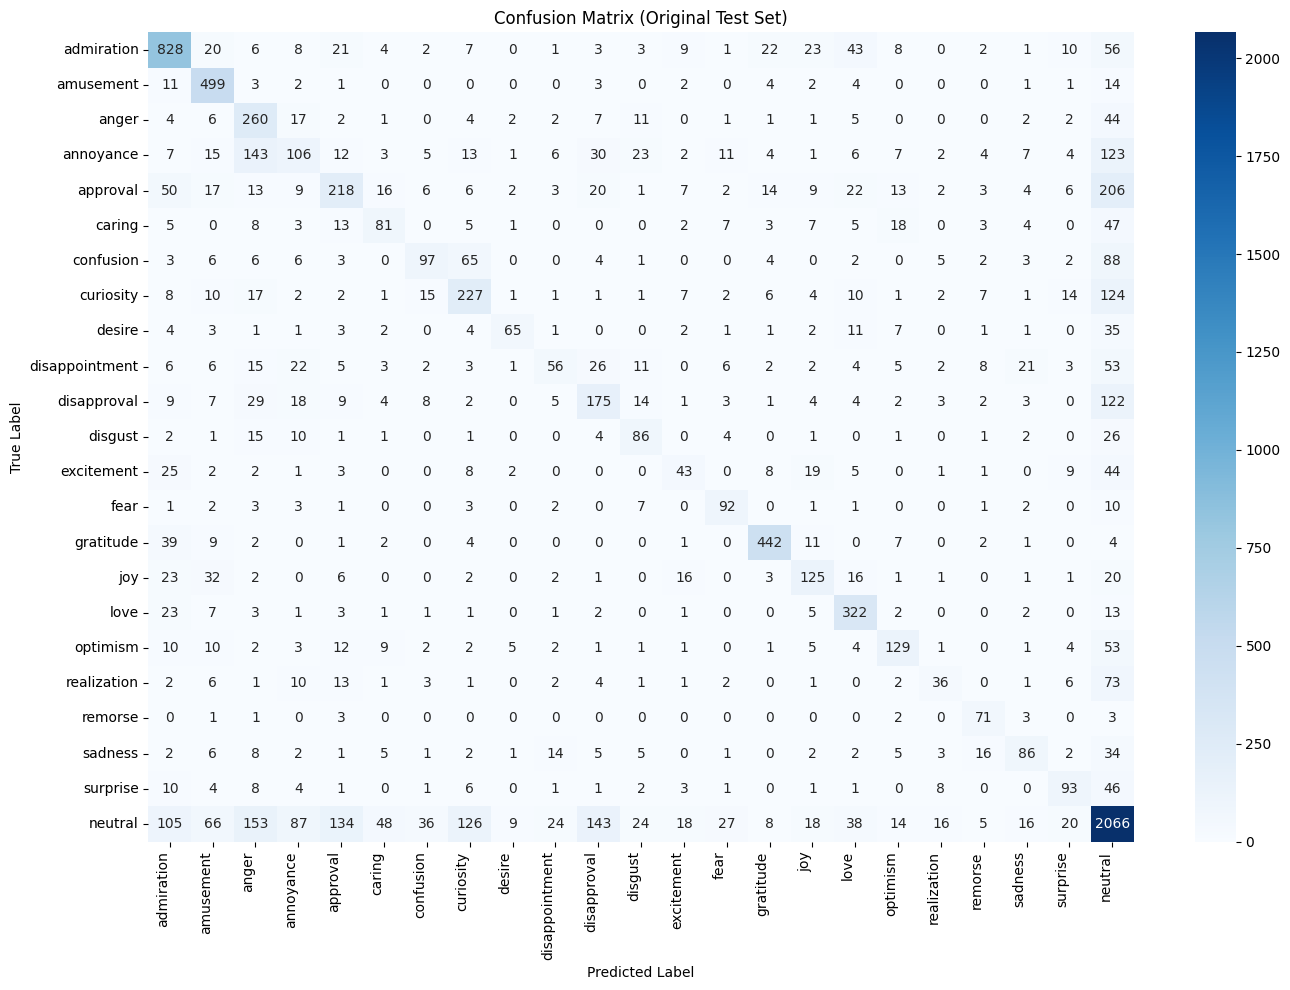

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer # Import necessary classes

# Define the local path where the model and tokenizer are saved (using the path from hxJEuHrTbYgl)
load_path_local_original = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\goemotion\roberta_classifierog"

# Load the trained model and tokenizer
loaded_model = AutoModelForSequenceClassification.from_pretrained(load_path_local_original)
loaded_tokenizer = AutoTokenizer.from_pretrained(load_path_local_original)

print(f"Original model and tokenizer loaded from {load_path_local_original}")


# Ensure the loaded model is in evaluation mode and on the correct device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model.to(device)
loaded_model.eval()

# Create a DataLoader for the test dataset
# Assuming test_dataset_original is the original test dataset with remapped labels
if 'test_dataset_original' in globals():
    test_dataloader_eval = DataLoader(test_dataset_original, batch_size=32)
    print("Using original test dataset for evaluation.")
    # Get the label mapping from the original dataset processing (from d30fa812)
    if 'label_mapping_original' in globals():
         remap = label_mapping_original
         inv_map = {v: k for k, v in remap.items()}
         print("Using label mapping from original dataset processing.")
    else:
         print("Error: label_mapping_original not found. Cannot map to emotion names. Using numerical labels for report/matrix.")
         inv_map = None # Indicates fallback to numerical labels

else:
    print("Error: test_dataset_original not found. Cannot perform evaluation.")
    test_dataloader_eval = None # Prevent errors in the loop
    inv_map = None


predictions = []
true_labels = []

if test_dataloader_eval:
    # Get predictions on the test dataset using the loaded model
    with torch.no_grad():
        for batch in test_dataloader_eval:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device) # These should be the remapped labels

            outputs = loaded_model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())


    # Define the go_emotions_label_to_emotion mapping here (copied for consistency)
    go_emotions_label_to_emotion = {
        0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance', 4: 'approval',
        5: 'caring', 6: 'confusion', 7: 'curiosity', 8: 'desire', 9: 'disappointment',
        10: 'disapproval', 11: 'disgust', 12: 'embarrassment', 13: 'excitement',
        14: 'fear', 15: 'gratitude', 16: 'grief', 17: 'joy', 18: 'love',
        19: 'nervousness', 20: 'optimism', 21: 'pride', 22: 'realization', 23: 'relief',
        24: 'remorse', 25: 'sadness', 26: 'surprise', 27: 'neutral'
    }

    # Sorted list of remapped labels present in the true labels
    remapped_labels_present = sorted(set(true_labels))

    # Map each remapped index to original label then to emotion name
    emotion_names = []
    if inv_map and go_emotions_label_to_emotion:
        for rem in remapped_labels_present:
            orig = inv_map.get(rem, -1) # Use .get with a default for safety
            emotion_name = go_emotions_label_to_emotion.get(orig, f"label_{orig}")
            emotion_names.append(emotion_name)

        # If the generated emotion_names list is empty or its length doesn't match the number of unique remapped labels,
        # fall back to using remapped numerical labels as names.
        if not emotion_names or len(emotion_names) != len(remapped_labels_present):
             print("Warning: Could not generate emotion names for report/matrix, falling back to numerical labels.")
             emotion_names = [str(i) for i in remapped_labels_present]
    else:
        print("Warning: Label mapping or emotion names mapping not fully available. Falling back to numerical labels for report/matrix.")
        # Fallback to using remapped numerical labels as names
        emotion_names = [str(i) for i in remapped_labels_present]


    # Classification report
    print("Classification Report:")
    print(classification_report(
        true_labels,
        predictions,
        labels=remapped_labels_present,
        target_names=emotion_names,
        zero_division=0
    ))

    # Confusion matrix
    conf_matrix = confusion_matrix(true_labels, predictions, labels=remapped_labels_present)

    # Plot confusion matrix
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=emotion_names,
        yticklabels=emotion_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Original Test Set)')
    plt.xticks(rotation=90, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Evaluation skipped due to missing test dataset or label mapping.")